# A Multidimensional Framework for Economic Uncertainty Quantification
## Composite Economic Uncertainty Index (CEUI)
### Hidalgo-Pérez & Navarro Pablo (2026)

---

**Principio de este notebook:** cada número que aparece en el paper tiene exactamente una celda de origen aquí.  
Ejecutar las celdas de arriba a abajo reproduce todos los resultados del paper sin depender del estado de sesión.

**Estructura:**
1. Carga y exploración del vintage triangle (`cntr.csv`)
2. Cálculo de `sigma_rev` — variable dependiente del paper
3. *(próximas celdas)* Forecasts de los 5 modelos
4. *(próximas celdas)* Construcción del CEUI (3 dimensiones)
5. *(próximas celdas)* Regresión CEUI vs sigma_rev

---
## MÓDULO 1 — Carga y exploración del vintage triangle

**Qué es `cntr.csv`:**  
El vintage triangle del PIB español (CNTR, INE). Una matriz donde:
- Cada **fila** es un trimestre del PIB (período de referencia)
- Cada **columna** es una fecha de publicación del INE (vintage)
- Cada **celda** es la estimación del PIB de ese trimestre según ese vintage
- Las **celdas vacías** indican que el INE aún no había publicado esa estimación

**Output esperado de este módulo:**
- Dimensiones confirmadas: 144 trimestres × 107 vintages
- Rango temporal claro
- Un plot del triángulo que muestre el patrón de cobertura

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Configuración de rutas ──────────────────────────────────────────────────
# Ajusta esta ruta a donde tengas cntr.csv en tu máquina
# ── Configuración de rutas ──────────────────────────────────────────────────
PATH_CNTR = r'C:\Users\Usuario\Documents\Github\Entropía\replica_pavia_2018\datos\cntr2.xlsx'
# ── Rutas de salida ──────────────────────────────────────────────────────────
PATH_FIGURES = r'C:\Users\Usuario\Documents\Github\Entropía\risk_analysis\paper_tex\figures'
PATH_TABLES  = r'C:\Users\Usuario\Documents\Github\Entropía\risk_analysis\paper_tex\tables'
os.makedirs(PATH_FIGURES, exist_ok=True)
os.makedirs(PATH_TABLES,  exist_ok=True)


df_raw = pd.read_excel(PATH_CNTR, sheet_name='cntr', header=None, skiprows=1)

# Ahora fila 0 = year, trim, fechas
header = [str(v) for v in df_raw.iloc[0]]
header[0] = 'year'
header[1] = 'trim'
df_raw.columns = header
df_raw = df_raw.iloc[1:].reset_index(drop=True)

# Convertir y limpiar
df_raw['year'] = pd.to_numeric(df_raw['year'], errors='coerce').ffill()
df_raw['trim'] = pd.to_numeric(df_raw['trim'], errors='coerce')
df_raw = df_raw.dropna(subset=['year', 'trim'])
df_raw = df_raw[df_raw['year'] >= 1995]
df_raw = df_raw[df_raw['trim'].isin([1.0, 2.0, 3.0, 4.0])].reset_index(drop=True)
df_raw['year'] = df_raw['year'].astype(int)
df_raw['trim'] = df_raw['trim'].astype(int)

vintage_cols = [c for c in df_raw.columns if '/' in str(c)]
print(f"Filas: {len(df_raw)} | Vintages: {len(vintage_cols)}")
print(f"Primer vintage: {vintage_cols[0]}")
print(f"Último vintage: {vintage_cols[-1]}")

print(f"Filas: {len(df_raw)} | Vintages: {len(vintage_cols)}")
print(df_raw[['year', 'trim']].head(8))

                
meta_cols    = ['year', 'trim']

print('=== ESTRUCTURA DEL VINTAGE TRIANGLE ===')
print(f'Trimestres (filas) : {len(df_raw)}')
print(f'Vintages  (cols)   : {len(vintage_cols)}')
print(f'Primer vintage     : {vintage_cols[0]}')
print(f'Último vintage     : {vintage_cols[-1]}')
print(f'Years disponibles  : {sorted(df_raw["year"].dropna().unique())}')
print(f'Trims disponibles  : {sorted(df_raw["trim"].unique())}')

Filas: 121 | Vintages: 106
Primer vintage: 22/11/2005 17:56
Último vintage: 25/06/2025 9:05
Filas: 121 | Vintages: 106
   year  trim
0  1995     1
1  1995     2
2  1995     3
3  1995     4
4  1996     1
5  1996     2
6  1996     3
7  1996     4
=== ESTRUCTURA DEL VINTAGE TRIANGLE ===
Trimestres (filas) : 121
Vintages  (cols)   : 106
Primer vintage     : 22/11/2005 17:56
Último vintage     : 25/06/2025 9:05
Years disponibles  : [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Trims disponibles  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)

In [3]:
# ── Convertir a formato largo (long format) ──────────────────────────────────
# Cada fila = un par (trimestre_referencia, vintage) con su valor de PIB

df_long = df_raw.melt(
    id_vars=meta_cols,
    value_vars=vintage_cols,
    var_name='vintage_str',
    value_name='pib'
)

# Convertir vintage a fecha
df_long['vintage_date'] = pd.to_datetime(df_long['vintage_str'], dayfirst=True)

# Eliminar NaNs (el INE aún no había publicado)
df_long = df_long.dropna(subset=['pib', 'year', 'trim'])
df_long['year'] = df_long['year'].astype(int)
df_long['trim'] = df_long['trim'].astype(int)

# Crear índice de período de referencia
df_long['period'] = pd.PeriodIndex(
    [f"{y}Q{q}" for y, q in zip(df_long['year'], df_long['trim'])],
    freq='Q'
)

# Ordenar
df_long = df_long.sort_values(['period', 'vintage_date']).reset_index(drop=True)

print('=== FORMATO LARGO ===')
print(f'Total observaciones: {len(df_long):,}')
print(f'Períodos únicos    : {df_long["period"].nunique()}')
print(f'Rango de períodos  : {df_long["period"].min()} → {df_long["period"].max()}')
print(f'Rango de valores   : {df_long["pib"].min():.1f} → {df_long["pib"].max():.1f}')
print()
print('Primeras filas:')
print(df_long[['period', 'vintage_date', 'pib']].head(8).to_string(index=False))

=== FORMATO LARGO ===
Total observaciones: 9,421
Períodos únicos    : 121
Rango de períodos  : 1995Q1 → 2025Q1
Rango de valores   : 63.7 → 122.0

Primeras filas:
period        vintage_date        pib
1995Q1 2005-11-22 17:56:00  63.667711
1995Q1 2006-02-21 21:59:00  63.667711
1995Q1 2006-05-23 12:57:00  63.667711
1995Q1 2006-08-29 20:58:00  63.667711
1995Q1 2006-11-21 10:41:00  63.667711
1995Q1 2007-02-20 21:01:00  63.667711
1995Q1 2007-05-22 20:45:00  63.667711
1995Q1 2007-08-28 22:43:00  63.667711


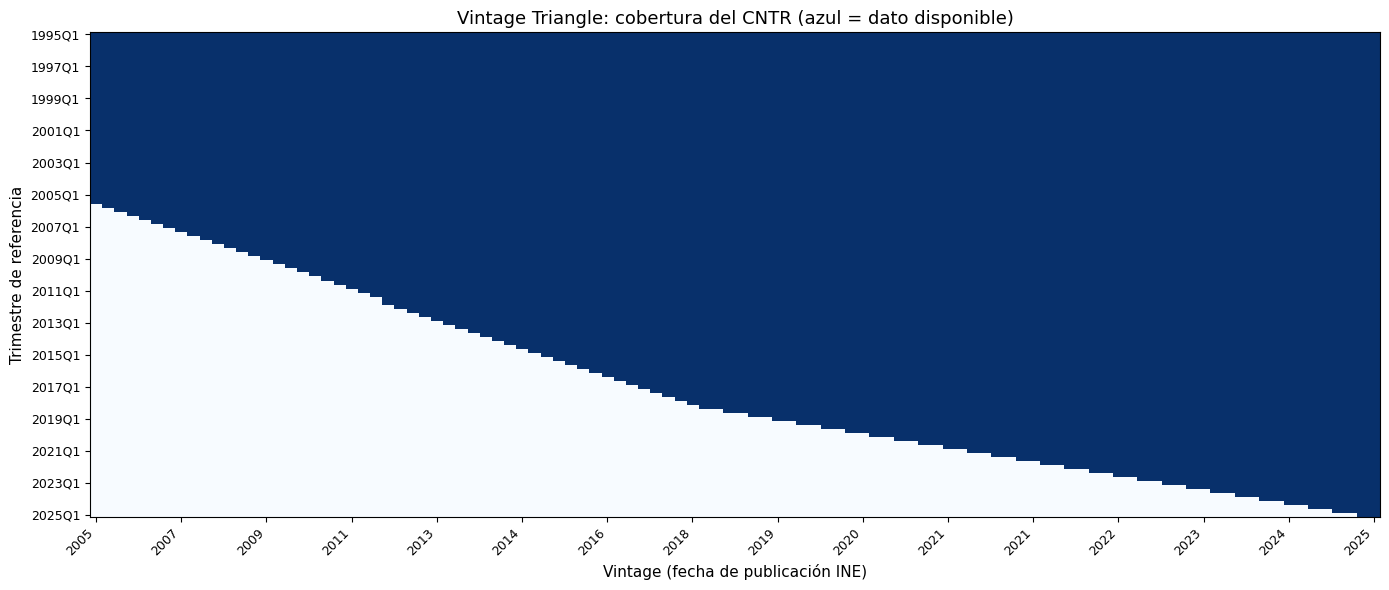

La forma triangular es visible: los trimestres recientes (parte inferior)
solo tienen datos en los vintages más recientes (parte derecha).


In [4]:
# ── Plot de cobertura del triángulo ──────────────────────────────────────────
# Muestra visualmente qué celdas tienen dato y cuáles son NaN

# Reconstruir matriz para el heatmap
pivot = df_raw.set_index(['year', 'trim'])[vintage_cols]
coverage_matrix = pivot.notna().astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(coverage_matrix.values, aspect='auto', cmap='Blues', 
               origin='upper', vmin=0, vmax=1)

# Etiquetas de eje X (vintages — mostrar solo algunos)
step = max(1, len(vintage_cols) // 15)
xtick_positions = list(range(0, len(vintage_cols), step))
xtick_labels = [
    pd.to_datetime(vintage_cols[i], dayfirst=True).strftime('%Y')
    for i in xtick_positions
]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=9)

# Etiquetas eje Y (trimestres — mostrar solo algunos)
n_rows = len(coverage_matrix)
step_y = max(1, n_rows // 15)
ytick_positions = list(range(0, n_rows, step_y))
ytick_labels = []
for i in ytick_positions:
    y, q = pivot.index[i]
    if pd.notna(y) and pd.notna(q):
        ytick_labels.append(f"{int(y)}Q{int(q)}")
    else:
        ytick_labels.append("")
        
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels, fontsize=9)

ax.set_xlabel('Vintage (fecha de publicación INE)', fontsize=11)
ax.set_ylabel('Trimestre de referencia', fontsize=11)
ax.set_title('Vintage Triangle: cobertura del CNTR (azul = dato disponible)', fontsize=13)
plt.tight_layout()
plt.show()

print('La forma triangular es visible: los trimestres recientes (parte inferior)\n'
      'solo tienen datos en los vintages más recientes (parte derecha).')

---
## MÓDULO 2 — Cálculo de `sigma_rev` (variable dependiente)

**Definición:** Para cada trimestre de referencia `t`, `sigma_rev(t)` es la
desviación estándar de todas las estimaciones que el INE ha publicado para ese trimestre
a lo largo de los distintos vintages.

Formalmente:
$$\sigma_{\text{rev},t} = \text{std}\bigl(\{\text{PIB}_{t,v} : v \in V_t\}\bigr)$$

donde $V_t$ es el conjunto de vintages que ya han publicado el trimestre $t$.

**Nota:** Los valores de `cntr.csv` son niveles del PIB (millones de euros encadenados).
Antes de calcular revisiones, los transformamos a **tasas de crecimiento interanual** (t/t-4)
para que las revisiones sean comparables entre períodos y estén en la misma escala
que los forecasts de los modelos.

**Output esperado:**
- Serie `sigma_rev` con una observación por trimestre
- Valores más altos en crisis (GFC 2008, deuda soberana 2011–2012, COVID 2020)
- Tabla resumen por régimen (claims A5–A8 del paper)

In [5]:
# ── Paso 1: convertir niveles a tasas de crecimiento interanual ──────────────
# Para cada vintage, calcular variación % respecto al mismo trimestre del año anterior

# Pivotar a matriz wide: filas=períodos, cols=vintages
df_pivot = df_long.pivot_table(
    index='period', columns='vintage_date', values='pib', aggfunc='last'
)
df_pivot = df_pivot.sort_index()

# Tasa de crecimiento interanual para cada vintage
# pct_change(4) = (t / t-4) - 1, multiplicado por 100 para expresar en %
df_growth = df_pivot.pct_change(4) * 100

print('=== TASAS DE CRECIMIENTO INTERANUAL ===')
print(f'Períodos: {df_growth.index.min()} → {df_growth.index.max()}')
print(f'Vintages: {len(df_growth.columns)}')
vals = pd.to_numeric(df_growth.values.flatten(), errors='coerce')
print(f'Rango de tasas: {np.nanmin(vals):.2f}% → {np.nanmax(vals):.2f}%')
print()
# Muestra para 2020 (donde esperamos valores extremos)
covid_periods = [p for p in df_growth.index if str(p).startswith('2020')]
if covid_periods:
    print('Tasas para 2020 (primer y último vintage disponible):')
    for p in covid_periods:
        row = df_growth.loc[p].dropna()
        if len(row) >= 2:
            print(f'  {p}: primera estimación={row.iloc[0]:.2f}%, última={row.iloc[-1]:.2f}%, '
                  f'n_vintages={len(row)}')

=== TASAS DE CRECIMIENTO INTERANUAL ===
Períodos: 1995Q1 → 2025Q1
Vintages: 106
Rango de tasas: -22.10% → 19.78%

Tasas para 2020 (primer y último vintage disponible):
  2020Q1: primera estimación=-4.10%, última=-4.18%, n_vintages=42
  2020Q2: primera estimación=-22.10%, última=-21.45%, n_vintages=40
  2020Q3: primera estimación=-8.72%, última=-9.13%, n_vintages=38
  2020Q4: primera estimación=-9.05%, última=-8.99%, n_vintages=36


In [6]:
# ── Paso 2: sigma_rev con ventana de 2 años naturales ────────────────────────
START_PERIOD = pd.Period('2004Q1', freq='Q')
WINDOW_YEARS = 2

records = []

for period in df_pivot.index:
    if period < START_PERIOD:
        continue

    # Serie de estimaciones para este trimestre (todos los vintages)
    row = df_growth.loc[period].dropna()
    if len(row) < 3:
        continue

    # Fecha de primera publicación de este trimestre
    first_vintage_date = row.index[0]

    # Filtrar solo vintages dentro de los 2 años siguientes
    cutoff = first_vintage_date + pd.DateOffset(years=WINDOW_YEARS)
    row_window = row[row.index <= cutoff]

    if len(row_window) < 3:
        continue

    records.append({
        'period'         : period,
        'sigma_rev'      : row_window.std(),
        'mae_rev'        : (row_window - row_window.iloc[-1]).abs().mean(),
        'n_vintages'     : len(row_window),
        'first_vintage'  : first_vintage_date,
        'last_vintage'   : row_window.index[-1],
    })

sigma_df = pd.DataFrame(records).set_index('period')

print('=== SIGMA_REV (ventana 2 años, desde 2004Q1) ===')
print(f'Períodos          : {len(sigma_df)}')
print(f'Rango             : {sigma_df.index.min()} → {sigma_df.index.max()}')
print(f'Vintages por período: min={sigma_df.n_vintages.min()}, '
      f'media={sigma_df.n_vintages.mean():.1f}, max={sigma_df.n_vintages.max()}')
print(f'\nMAE global        : {sigma_df.mae_rev.mean():.4f} pp')
print(f'Sigma global      : {sigma_df.sigma_rev.mean():.4f} pp')
print(f'\nMáximo sigma_rev  : {sigma_df.sigma_rev.max():.4f} pp  '
      f'({sigma_df.sigma_rev.idxmax()})')
print(f'Mínimo sigma_rev  : {sigma_df.sigma_rev.min():.4f} pp  '
      f'({sigma_df.sigma_rev.idxmin()})')

# Exportar para uso en el resto del notebook
sigma_rev = sigma_df['sigma_rev']
mae_rev   = sigma_df['mae_rev']

n_vintages_per_period = df_growth.notna().sum(axis=1)
MIN_VINTAGES = 3

=== SIGMA_REV (ventana 2 años, desde 2004Q1) ===
Períodos          : 84
Rango             : 2004Q1 → 2024Q4
Vintages por período: min=4, media=11.0, max=17

MAE global        : 0.1816 pp
Sigma global      : 0.1460 pp

Máximo sigma_rev  : 0.6365 pp  (2021Q3)
Mínimo sigma_rev  : 0.0101 pp  (2009Q4)


In [7]:
# ── Paso 3: tabla de revisiones por régimen (claims A5-A8 del paper) ─────────
# Comparar MAE en períodos normales vs crisis

# Definición de regímenes según el paper
regimes = {
    'Normal'        : lambda p: not any([
                        (pd.Period('2008Q3') <= p <= pd.Period('2009Q2')),
                        (pd.Period('2011Q4') <= p <= pd.Period('2013Q3')),
                        (pd.Period('2020Q1') <= p <= pd.Period('2022Q2'))
                      ]),
    'GFC'           : lambda p: pd.Period('2008Q3') <= p <= pd.Period('2009Q2'),
    'Sovereign Debt': lambda p: pd.Period('2011Q4') <= p <= pd.Period('2013Q3'),
    'COVID-19'      : lambda p: pd.Period('2020Q1') <= p <= pd.Period('2022Q2'),
}

print('=== REVISIONES POR RÉGIMEN (Tabla 3 del paper) ===')
print(f'{"Régimen":<20} {"N":>5} {"MAE medio":>12} {"Ratio vs Normal":>16}')
print('-' * 58)

mae_normal = None
for regime_name, condition in regimes.items():
    mask = mae_rev.index.map(condition)
    subset = mae_rev[mask]
    if len(subset) == 0:
        continue
    mae_mean = subset.mean()
    if regime_name == 'Normal':
        mae_normal = mae_mean
        ratio_str = '1.0x (baseline)'
    else:
        ratio = mae_mean / mae_normal if mae_normal else float('nan')
        ratio_str = f'{ratio:.1f}x'
    print(f'{regime_name:<20} {len(subset):>5} {mae_mean:>12.3f} {ratio_str:>16}')

print()
print('NOTA: Compara estos ratios con los del paper: 1.8x (GFC), 3.6x (deuda), 2.9x (COVID)')
print('Si los ratios no coinciden, revisar definición de períodos de crisis o de MAE.')

=== REVISIONES POR RÉGIMEN (Tabla 3 del paper) ===
Régimen                  N    MAE medio  Ratio vs Normal
----------------------------------------------------------
Normal                  62        0.141  1.0x (baseline)
GFC                      4        0.200             1.4x
Sovereign Debt           8        0.242             1.7x
COVID-19                10        0.379             2.7x

NOTA: Compara estos ratios con los del paper: 1.8x (GFC), 3.6x (deuda), 2.9x (COVID)
Si los ratios no coinciden, revisar definición de períodos de crisis o de MAE.


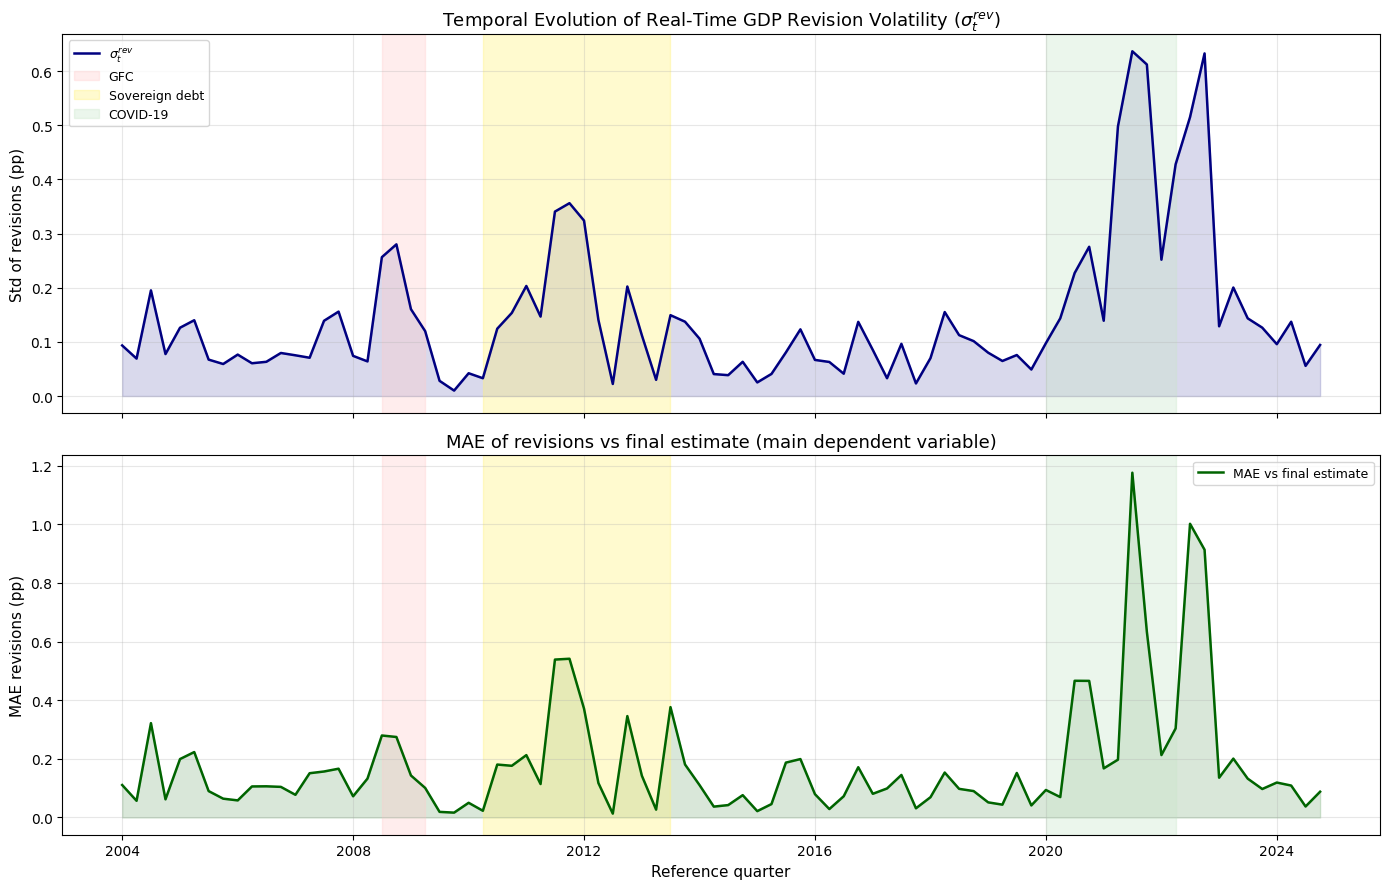

✅ fig1_revision_volatility guardada


In [8]:
# ── Paso 4: plot de sigma_rev a lo largo del tiempo ──────────────────────────

# ── Figura 1: sigma_rev temporal ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
x  = sigma_rev.index.to_timestamp()
x2 = mae_rev.index.to_timestamp()

crisis_spans = [
    (pd.Period('2008Q3').to_timestamp(), pd.Period('2009Q2').to_timestamp(), '#ffcccc', 'GFC'),
    (pd.Period('2010Q2').to_timestamp(), pd.Period('2013Q3').to_timestamp(), '#fff176', 'Sovereign debt'),
    (pd.Period('2020Q1').to_timestamp(), pd.Period('2022Q2').to_timestamp(), '#c8e6c9', 'COVID-19'),
]

ax = axes[0]
ax.plot(x, sigma_rev.values, color='navy', linewidth=1.8, label=r'$\sigma^{rev}_t$')
ax.fill_between(x, 0, sigma_rev.values, alpha=0.15, color='navy')
for start, end, color, label in crisis_spans:
    ax.axvspan(start, end, alpha=0.35, color=color, label=label)
ax.set_ylabel('Std of revisions (pp)', fontsize=11)
ax.set_title(r'Temporal Evolution of Real-Time GDP Revision Volatility ($\sigma^{rev}_t$)', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(x2, mae_rev.values, color='darkgreen', linewidth=1.8, label='MAE vs final estimate')
ax2.fill_between(x2, 0, mae_rev.values, alpha=0.15, color='darkgreen')
for start, end, color, label in crisis_spans:
    ax2.axvspan(start, end, alpha=0.35, color=color)
ax2.set_ylabel('MAE revisions (pp)', fontsize=11)
ax2.set_xlabel('Reference quarter', fontsize=11)
ax2.set_title('MAE of revisions vs final estimate (main dependent variable)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(PATH_FIGURES, 'fig1_revision_volatility.pdf'),
            bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(PATH_FIGURES, 'fig1_revision_volatility.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig1_revision_volatility guardada')

In [9]:
# ── Paso 5: tabla de revisiones por trimestre calendario (Tabla 2 del paper) ─

print('=== MAE POR TRIMESTRE CALENDARIO (Tabla 2 del paper) ===')
print(f'{"Trim":>6} {"N obs":>7} {"MAE medio":>12} {"Mean Error":>13}')
print('-' * 42)

for q in [1, 2, 3, 4]:
    mask_q = mae_rev.index.map(lambda p: p.quarter == q)
    subset_mae = mae_rev[mask_q]
    # Mean error (con signo) requiere la media de las revisiones, no del absoluto
    # Revisión = (última estimación - primera estimación)
    first_est = df_growth[df_growth.notna().any(axis=1)].apply(
        lambda row: row.dropna().iloc[0] if row.dropna().shape[0] > 0 else np.nan, axis=1
    )
    last_est = df_growth.apply(
        lambda row: row.dropna().iloc[-1] if row.dropna().shape[0] > 0 else np.nan, axis=1
    )
    revision = last_est - first_est
    revision = revision[n_vintages_per_period >= MIN_VINTAGES]
    mask_q2 = revision.index.map(lambda p: p.quarter == q)
    mean_err = revision[mask_q2].mean()
    print(f'Q{q:1d}    {len(subset_mae):>7} {subset_mae.mean():>12.3f} {mean_err:>13.3f}')

# Total
print('-' * 42)
revision_all = last_est - first_est
revision_all = revision_all[n_vintages_per_period >= MIN_VINTAGES]
print(f'{"Total":<6} {len(mae_rev):>7} {mae_rev.mean():>12.3f} {revision_all.mean():>13.3f}')
print()
print('NOTA: Compara con Tabla 2 del paper. MAE global paper = 0.203 pp.')

=== MAE POR TRIMESTRE CALENDARIO (Tabla 2 del paper) ===
  Trim   N obs    MAE medio    Mean Error
------------------------------------------
Q1         21        0.123        -0.012
Q2         21        0.111         0.005
Q3         21        0.266         0.045
Q4         21        0.226        -0.007
------------------------------------------
Total       84        0.182         0.008

NOTA: Compara con Tabla 2 del paper. MAE global paper = 0.203 pp.


In [10]:
import os


# ── Tabla 2: MAE por trimestre ───────────────────────────────────────────────
first_est = df_growth.apply(
    lambda row: row.dropna().iloc[0] if len(row.dropna()) > 0 else np.nan, axis=1)
last_est = df_growth.apply(
    lambda row: row.dropna().iloc[-1] if len(row.dropna()) > 0 else np.nan, axis=1)
revision = (last_est - first_est)[n_vintages_per_period >= MIN_VINTAGES]

rows_t2 = []
for q in [1, 2, 3, 4]:
    mask_q  = pd.Series(mae_rev.index.map(lambda p: p.quarter == q), index=mae_rev.index)
    mask_q2 = pd.Series(revision.index.map(lambda p: p.quarter == q), index=revision.index)
    rows_t2.append({
        'Quarter'   : f'Q{q}',
        'Mean Error': round(revision[mask_q2].mean(), 3),
        'MAE'       : round(mae_rev[mask_q].mean(), 3),
        'Obs'       : int(mask_q.sum())
    })
rows_t2.append({
    'Quarter'   : 'Average',
    'Mean Error': round(revision.mean(), 3),
    'MAE'       : round(mae_rev.mean(), 3),
    'Obs'       : len(mae_rev)
})

table2 = pd.DataFrame(rows_t2)
print(table2)

latex_t2 = (
    "\\begin{table}[t]\n\\centering\n"
    "\\caption{Revision Error Statistics by Quarter (2004--2024)}\n"
    "\\label{tab:revision_errors}\n"
    "\\begin{tabular}{lccc}\n\\toprule\n"
    "Quarter & Mean Error & MAE & Obs \\\\\n\\midrule\n"
)
for _, r in table2.iterrows():
    latex_t2 += f"{r['Quarter']} & {r['Mean Error']:.3f} & {r['MAE']:.3f} & {r['Obs']} \\\\\n"
latex_t2 += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"

with open(os.path.join(PATH_TABLES, 'tab_revision_errors.tex'), 'w') as f:
    f.write(latex_t2)
print('✅ tab_revision_errors.tex guardada')

# ── Tabla 3: amplificación por crisis ────────────────────────────────────────
regimes_def = {
    'Normal'          : lambda p: not any([
                            pd.Period('2008Q3') <= p <= pd.Period('2009Q2'),
                            pd.Period('2010Q2') <= p <= pd.Period('2013Q3'),
                            pd.Period('2020Q1') <= p <= pd.Period('2022Q2')]),
    'Financial Crisis': lambda p: pd.Period('2008Q3') <= p <= pd.Period('2009Q2'),
    'Sovereign Debt'  : lambda p: pd.Period('2010Q2') <= p <= pd.Period('2013Q3'),
    'COVID-19'        : lambda p: pd.Period('2020Q1') <= p <= pd.Period('2022Q2'),
}

rows_t3  = []
mae_normal = None
for name, cond in regimes_def.items():
    mask   = pd.Series(mae_rev.index.map(cond), index=mae_rev.index)
    subset = mae_rev[mask]
    mae_m  = subset.mean()
    if name == 'Normal':
        mae_normal = mae_m
        ratio = '1.0x'
    else:
        ratio = f'{mae_m/mae_normal:.1f}x'
    rows_t3.append({'Period': name, 'MAE': round(mae_m, 3),
                    'Obs': len(subset), 'Amplif. Factor': ratio})

table3 = pd.DataFrame(rows_t3)
print(table3)

latex_t3 = (
    "\\begin{table}[t]\n\\centering\n"
    "\\caption{Crisis Amplification of Revision Errors}\n"
    "\\label{tab:crisis_amplification}\n"
    "\\begin{tabular}{lccc}\n\\toprule\n"
    "Period & MAE & Obs & Amplif. Factor \\\\\n\\midrule\n"
)
for _, r in table3.iterrows():
    latex_t3 += f"{r['Period']} & {r['MAE']:.3f} & {r['Obs']} & {r['Amplif. Factor']} \\\\\n"
latex_t3 += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"

with open(os.path.join(PATH_TABLES, 'tab_crisis_amplification.tex'), 'w') as f:
    f.write(latex_t3)
print('✅ tab_crisis_amplification.tex guardada')

   Quarter  Mean Error    MAE  Obs
0       Q1      -0.012  0.123   21
1       Q2       0.005  0.111   21
2       Q3       0.045  0.266   21
3       Q4      -0.007  0.226   21
4  Average       0.008  0.182   84
✅ tab_revision_errors.tex guardada
             Period    MAE  Obs Amplif. Factor
0            Normal  0.134   56           1.0x
1  Financial Crisis  0.200    4           1.5x
2    Sovereign Debt  0.227   14           1.7x
3          COVID-19  0.379   10           2.8x
✅ tab_crisis_amplification.tex guardada


---
## MODULE 3 — Rolling Forecasts: Five-Model Ensemble (2015Q1–2024Q4)

This module generates the **out-of-sample forecast record** that feeds the CEUI.
For each quarter in the evaluation window, each model is re-estimated using only
information available up to $t-1$, simulating real-time forecasting conditions.

### Forecasting models

1. **VAR** — Vector Autoregression with up to 4 lags (AIC selection). Includes GDP
   and 9 macroeconomic predictors (industrial production, employment, investment,
   PMI, CLI). Serves as the linear multivariate benchmark.

2. **ARIMA** — Univariate ARIMA(4,0,1) on GDP growth. Pure time-series baseline
   with no external predictors.

3. **Random Forest (RF)** — Non-linear ensemble using lagged GDP values and
   contemporaneous predictors as features. Trained with 100 trees; features
   standardised at each rolling step.

4. **LSTM** — Long Short-Term Memory network with a sequence length of 8 quarters.
   Univariate on GDP growth; re-trained at each rolling step with early stopping
   (patience = 5).

5. **DFM** — Dynamic Factor Model with 1 common factor extracted from the full
   predictor set. Estimated via the EM algorithm at each rolling step.

### Rolling window protocol

- **Evaluation period:** 2015Q1 – 2024Q4 (40 quarters)
- **Training window:** expanding — all data available up to $t-1$
- **Minimum training observations:** 20 quarters
- **Predictor source:** latest available vintage of the INE/BDSICE monthly
  indicators, trimestralized by quarterly mean

### Output

A single DataFrame `forecasts_df` with one column per model plus `actual` (GDP
realised growth from `cntr2`). This is the direct input to Module 4 (CEUI
construction).

---

In [17]:
# =============================================================================
# MÓDULO 3 — Forecasts rolling de los 5 modelos (2015Q1–2024Q4)
# =============================================================================
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# ── Parámetros globales ───────────────────────────────────────────────────────
EVAL_START = pd.Period('2015Q1', freq='Q')
EVAL_END   = pd.Period('2024Q4', freq='Q')
EVAL_RANGE = pd.period_range(EVAL_START, EVAL_END, freq='Q')
N_LAGS_VAR = 4
N_LAGS_RF  = 6   # trimestres de historia para features del RF
N_LAGS_AR  = 4

print(f"Período de evaluación: {EVAL_START} → {EVAL_END}")
print(f"Total trimestres: {len(EVAL_RANGE)}")

# ── Cargar predictores mensuales ──────────────────────────────────────────────
PATH_CT = r'C:\Users\Usuario\Documents\Github\crisistrackerv2'
dir_m   = os.path.join(PATH_CT, 'data', 'Vintage', 'monthly', 'IIT2025')
latest  = sorted([f for f in os.listdir(dir_m) if f.endswith('_m_rev.xlsx')])[-1]

df_m = pd.read_excel(os.path.join(dir_m, latest))
df_m = df_m.rename(columns={'Unnamed: 0': 'Fecha'})
df_m.index = pd.PeriodIndex(df_m['Fecha'].tolist(), freq='M')
df_m.drop('Fecha', axis=1, inplace=True)

# Trimestrializar (media del trimestre)
df_q_pred = df_m.to_timestamp().resample('QE').mean().to_period('Q')

# Variables seleccionadas (cobertura desde ≤2001)
PREDICTORS = [
    'AFILIACIONES A LA SS. CVEC',
    'INDICE PRODUCCION INDUSTRIAL. INDUSTRIA MANUFACTURERA. CVEC',
    'INDICE PRODUCCION INDUSTRIAL. BIENES DE EQUIPO. CVEC',
    'INDICE PRODUCCION INDUSTRIAL. BIENES INTERMEDIOS. CVEC',
    'INDICADOR SINTETICO DE INVERSION EN CONSTRUCCION. CVEC',
    'INDICADOR SINTETICO DE INVERSION EN BIENES DE EQUIPO. CVEC',
    'VGE. INTERIORES. REAL. CVEC',
    'PMI. MANUFACTURAS. ESPAÑA',
    'COMPOSITE LEADING INDICATOR. ESPAÑA ( OCDE )',
]
df_q_pred = df_q_pred[PREDICTORS].copy()

# ── PIB desde cntr2 (último vintage disponible) ───────────────────────────────
# Usar la última columna de df_growth como serie "real" del PIB
gdp_series = df_growth.ffill(axis=1).iloc[:, -1].dropna()
gdp_series.name = 'PIB'

print(f"\nPIB disponible: {gdp_series.index.min()} → {gdp_series.index.max()}")
print(f"Predictores disponibles: {df_q_pred.index.min()} → {df_q_pred.index.max()}")

# ── Dataset combinado ─────────────────────────────────────────────────────────
df_all = pd.concat([gdp_series, df_q_pred], axis=1)
df_all = df_all.loc['2001Q1':].dropna(how='all')

print(f"Dataset combinado: {df_all.shape}")
print(f"Rango: {df_all.index.min()} → {df_all.index.max()}")

Período de evaluación: 2015Q1 → 2024Q4
Total trimestres: 40

PIB disponible: 1996Q1 → 2025Q1
Predictores disponibles: 1992Q1 → 2025Q3
Dataset combinado: (115, 10)
Rango: 1992Q1 → 2025Q3


In [21]:
# =============================================================================
# MÓDULO 3B — Rolling forecasts de los 5 modelos
# =============================================================================

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM as LSTMLayer, Dense
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Definir arquitectura LSTM fuera del loop para evitar retracing
SEQ_LEN = 8

def build_lstm():
    m = Sequential([
        LSTMLayer(16, input_shape=(SEQ_LEN, 1)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

# ── Loop principal ────────────────────────────────────────────────────────────
forecasts  = {m: {} for m in ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']}
n_total    = len(EVAL_RANGE)

# Forzar tipos numéricos en todo el dataset
df_all = df_all.apply(pd.to_numeric, errors='coerce')

for i, target in enumerate(EVAL_RANGE):
    train_end  = target - 1
    train_data = df_all.loc[:train_end].dropna()
    n_train    = len(train_data)

    print(f"\n[{i+1:2d}/{n_total}] {target}  —  entrenamiento hasta {train_end}  ({n_train} obs)")

    if n_train < 20:
        print(f"  ⚠ pocos datos, saltando")
        for m in forecasts:
            forecasts[m][target] = np.nan
        continue

    gdp_train = train_data['PIB']
    X_train   = train_data.drop(columns=['PIB'])

    # ── VAR ──────────────────────────────────────────────────────────────────
    print(f"  → VAR    ", end='', flush=True)
    try:
        var_data   = train_data.dropna()
        model_var  = VAR(var_data)
        lags       = max(1, model_var.select_order(maxlags=N_LAGS_VAR).aic)
        fitted_var = model_var.fit(lags)
        fc         = fitted_var.forecast(var_data.values[-lags:], steps=1)
        forecasts['VAR'][target] = fc[0, 0]
        print(f"✓  {fc[0,0]:+.3f}")
    except Exception as e:
        forecasts['VAR'][target] = np.nan
        print(f"✗  {str(e)[:40]}")

    # ── ARIMA ─────────────────────────────────────────────────────────────────
    print(f"  → ARIMA  ", end='', flush=True)
    try:
        fitted_ar  = ARIMA(gdp_train, order=(N_LAGS_AR, 0, 1)).fit()
        fc_ar      = fitted_ar.forecast(steps=1).iloc[0]
        forecasts['ARIMA'][target] = fc_ar
        print(f"✓  {fc_ar:+.3f}")
    except Exception as e:
        forecasts['ARIMA'][target] = np.nan
        print(f"✗  {str(e)[:40]}")

    # ── Random Forest ─────────────────────────────────────────────────────────
    print(f"  → RF     ", end='', flush=True)
    try:
        gdp_vals = gdp_train.values
        if len(gdp_vals) < N_LAGS_RF + 1:
            raise ValueError("serie demasiado corta")

        X_rf, y_rf = [], []
        for j in range(N_LAGS_RF, len(gdp_vals)):
            row = list(gdp_vals[j-N_LAGS_RF:j])
            row += list(X_train.iloc[j-1].fillna(0).values)
            X_rf.append(row)
            y_rf.append(gdp_vals[j])

        scaler   = StandardScaler()
        X_rf_sc  = scaler.fit_transform(X_rf)
        rf       = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_rf_sc, y_rf)

        x_pred    = list(gdp_vals[-N_LAGS_RF:])
        x_pred   += list(X_train.iloc[-1].fillna(0).values)
        fc_rf     = rf.predict(scaler.transform([x_pred]))[0]
        forecasts['RF'][target] = fc_rf
        print(f"✓  {fc_rf:+.3f}")
    except Exception as e:
        forecasts['RF'][target] = np.nan
        print(f"✗  {str(e)[:40]}")

    # ── LSTM ──────────────────────────────────────────────────────────────────
    print(f"  → LSTM   ", end='', flush=True)
    try:
        gdp_vals    = gdp_train.values.reshape(-1, 1)
        scaler_lstm = StandardScaler()
        gdp_sc      = scaler_lstm.fit_transform(gdp_vals)

        if len(gdp_sc) < SEQ_LEN + 1:
            raise ValueError("serie demasiado corta")

        X_lstm, y_lstm = [], []
        for j in range(SEQ_LEN, len(gdp_sc)):
            X_lstm.append(gdp_sc[j-SEQ_LEN:j])
            y_lstm.append(gdp_sc[j])
        X_lstm = np.array(X_lstm)
        y_lstm = np.array(y_lstm)

        model_lstm = build_lstm()
        model_lstm.fit(
            X_lstm, y_lstm,
            epochs=50, batch_size=8, verbose=0,
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
        )
        x_pred_lstm = gdp_sc[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
        pred_sc     = model_lstm.predict(x_pred_lstm, verbose=0)
        fc_lstm     = scaler_lstm.inverse_transform(pred_sc)[0, 0]
        forecasts['LSTM'][target] = fc_lstm
        print(f"✓  {fc_lstm:+.3f}")
    except Exception as e:
        forecasts['LSTM'][target] = np.nan
        print(f"✗  {str(e)[:40]}")

    # ── DFM ───────────────────────────────────────────────────────────────────
    print(f"  → DFM    ", end='', flush=True)
    try:
        dfm_data   = train_data.dropna()
        scaler_dfm = StandardScaler()
        dfm_sc     = pd.DataFrame(
            scaler_dfm.fit_transform(dfm_data),
            index=dfm_data.index, columns=dfm_data.columns
        )
        fitted_dfm = DynamicFactorMQ(dfm_sc, factors=1, factor_orders=1).fit(disp=False)
        fc_dfm     = fitted_dfm.forecast(steps=1)
        pib_idx    = list(dfm_data.columns).index('PIB')
        pred_unsc  = (fc_dfm.iloc[0, pib_idx] * scaler_dfm.scale_[pib_idx]
                      + scaler_dfm.mean_[pib_idx])
        forecasts['DFM'][target] = pred_unsc
        print(f"✓  {pred_unsc:+.3f}")
    except Exception as e:
        forecasts['DFM'][target] = np.nan
        print(f"✗  {str(e)[:40]}")

# ── Consolidar ────────────────────────────────────────────────────────────────
forecasts_df = pd.DataFrame(
    {m: pd.Series(forecasts[m]) for m in forecasts}
)
forecasts_df.index = pd.PeriodIndex(forecasts_df.index, freq='Q')
forecasts_df['actual'] = gdp_series.reindex(forecasts_df.index)

print('\n=== FORECASTS ROLLING (primeras 8 filas) ===')
print(forecasts_df.head(8).round(3))

print('\n=== COBERTURA POR MODELO ===')
for m in ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']:
    n_ok  = forecasts_df[m].notna().sum()
    n_nan = forecasts_df[m].isna().sum()
    print(f"  {m:<6}: {n_ok:2d} válidos  {n_nan:2d} NaN")

print('\n=== MAE POR MODELO ===')
for m in ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']:
    mae = (forecasts_df[m] - forecasts_df['actual']).abs().mean()
    print(f"  {m:<6}: {mae:.4f}")


[ 1/40] 2015Q1  —  entrenamiento hasta 2014Q4  (56 obs)
  → VAR    ✓  +3.824
  → ARIMA  ✓  +3.090
  → RF     ✓  +2.635
  → LSTM   ✓  +1.228
  → DFM    ✓  +2.541

[ 2/40] 2015Q2  —  entrenamiento hasta 2015Q1  (57 obs)
  → VAR    ✓  +4.328
  → ARIMA  ✓  +4.173
  → RF     ✓  +3.424
  → LSTM   ✓  +2.755
  → DFM    ✓  +3.582

[ 3/40] 2015Q3  —  entrenamiento hasta 2015Q2  (58 obs)
  → VAR    ✓  +4.189
  → ARIMA  ✓  +4.267
  → RF     ✓  +4.042
  → LSTM   ✓  +3.888
  → DFM    ✓  +4.216

[ 4/40] 2015Q4  —  entrenamiento hasta 2015Q3  (59 obs)
  → VAR    ✓  +4.485
  → ARIMA  ✓  +4.367
  → RF     ✓  +4.152
  → LSTM   ✓  +4.885
  → DFM    ✓  +4.307

[ 5/40] 2016Q1  —  entrenamiento hasta 2015Q4  (60 obs)
  → VAR    ✓  +4.291
  → ARIMA  ✓  +3.908
  → RF     ✓  +4.144
  → LSTM   ✓  +4.616
  → DFM    ✓  +4.139

[ 6/40] 2016Q2  —  entrenamiento hasta 2016Q1  (61 obs)
  → VAR    ✓  +4.405
  → ARIMA  ✓  +3.224
  → RF     ✓  +3.784
  → LSTM   ✓  +4.680
  → DFM    ✓  +3.569

[ 7/40] 2016Q3  —  entrenam

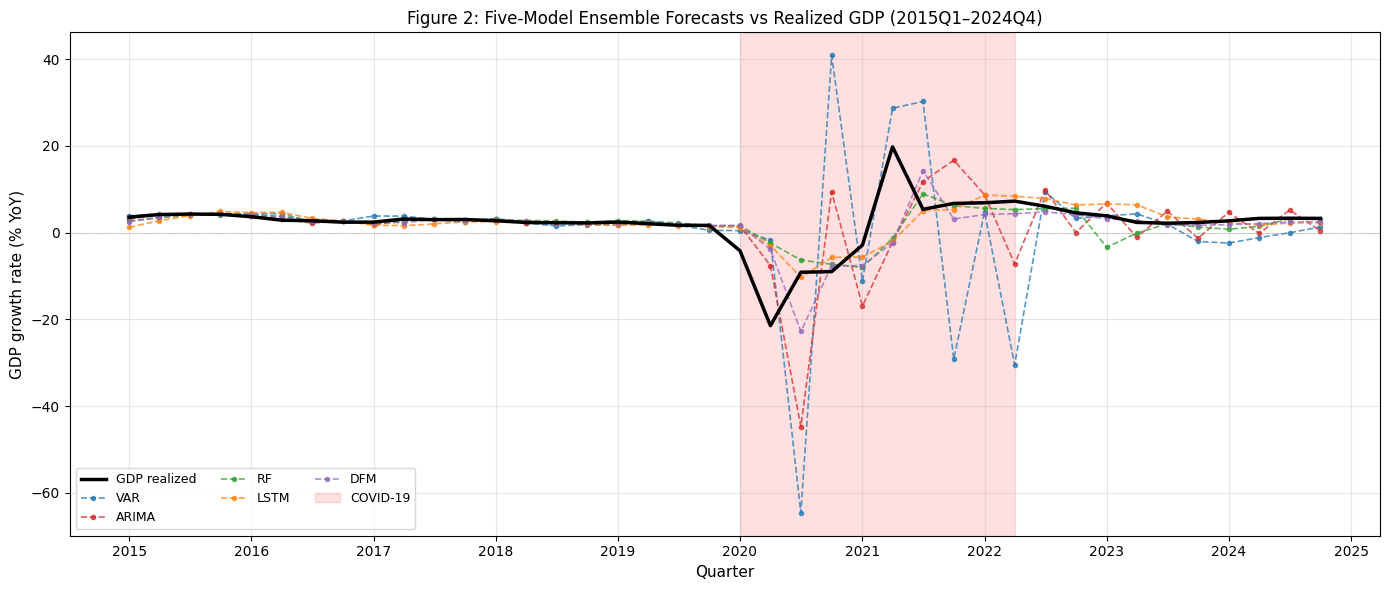

✅ fig2_ensemble_forecasts guardada


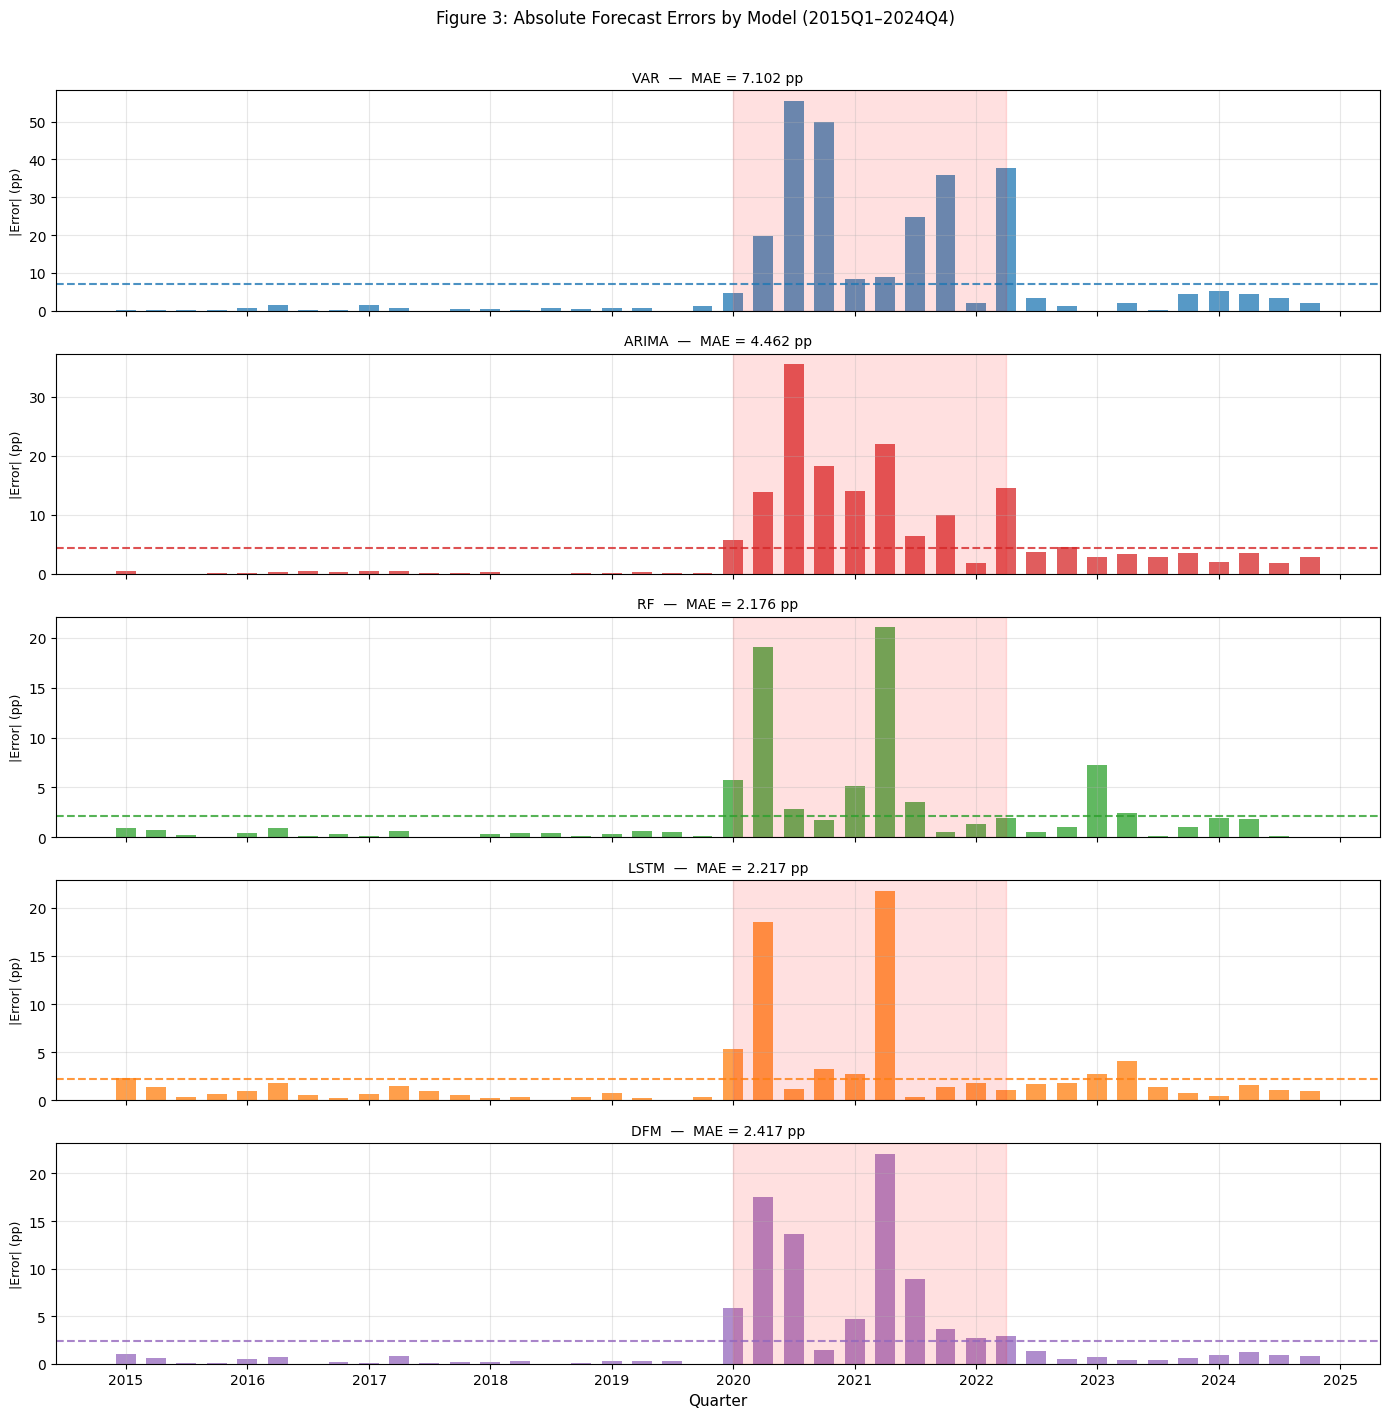

✅ fig3_forecast_errors guardada


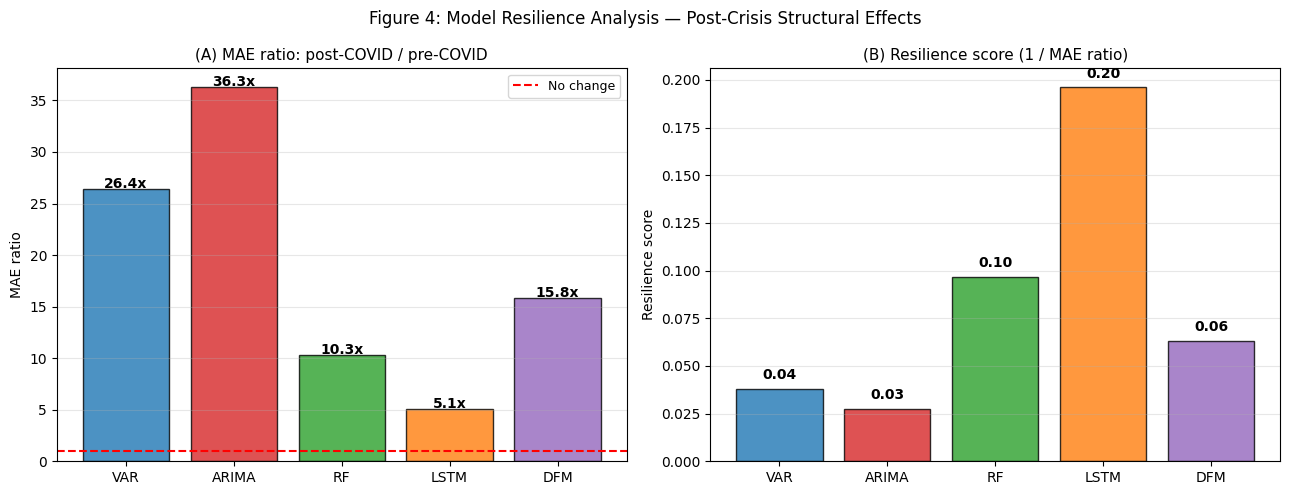

✅ fig4_model_resilience guardada

=== TABLA 1 PANEL A: Estadísticos descriptivos ===
              VAR   ARIMA      RF    LSTM     DFM
Mean        1.143   1.379   2.016   2.400   1.678
Std. Dev.  15.865   9.200   3.460   3.719   5.189
Min       -64.615 -44.712  -8.030 -10.315 -22.794
Max        40.908  16.680   8.944   8.656  14.287
N          40.000  40.000  40.000  40.000  40.000
✅ tab1_panel_a_descriptive.tex guardada

=== TABLA 4: Performance y resiliencia ===
Model  MAE (full)  RMSE (full)  MAE pre-COVID  MAE post-COVID  MAE ratio  Resilience
  VAR       7.102       15.469          0.519          13.685      26.39       0.038
ARIMA       4.462        8.615          0.239           8.684      36.30       0.028
   RF       2.176        4.920          0.384           3.968      10.33       0.097
 LSTM       2.217        4.811          0.728           3.707       5.09       0.196
  DFM       2.417        5.382          0.287           4.547      15.83       0.063
✅ tab4_model_performa

In [22]:
# =============================================================================
# MÓDULO 3C — Figuras y tablas de evaluación del ensemble
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

PATH_FIGURES = r'C:\Users\Usuario\Documents\Github\Entropía\risk_analysis\paper_tex\figures'
PATH_TABLES  = r'C:\Users\Usuario\Documents\Github\Entropía\risk_analysis\paper_tex\tables'

COLORS = {
    'VAR'  : '#1f77b4',
    'ARIMA': '#d62728',
    'RF'   : '#2ca02c',
    'LSTM' : '#ff7f0e',
    'DFM'  : '#9467bd',
    'actual': 'black'
}

COVID_START = pd.Period('2020Q1', freq='Q').to_timestamp()
COVID_END   = pd.Period('2022Q2', freq='Q').to_timestamp()
PRE_COVID   = pd.Period('2019Q4', freq='Q')

x = forecasts_df.index.to_timestamp()

# ── Figura 2: Forecasts vs PIB realizado ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x, forecasts_df['actual'], color='black', linewidth=2.5,
        label='GDP realized', zorder=5)
for m in ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']:
    ax.plot(x, forecasts_df[m], color=COLORS[m], linewidth=1.2,
            alpha=0.75, linestyle='--', marker='o', markersize=3, label=m)

ax.axvspan(COVID_START, COVID_END, alpha=0.12, color='red', label='COVID-19')
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set_ylabel('GDP growth rate (% YoY)', fontsize=11)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_title('Figure 2: Five-Model Ensemble Forecasts vs Realized GDP (2015Q1–2024Q4)',
             fontsize=12)
ax.legend(fontsize=9, ncol=3, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/fig2_ensemble_forecasts.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/fig2_ensemble_forecasts.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig2_ensemble_forecasts guardada')

# ── Figura 3: Errores absolutos por modelo ────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

for idx, m in enumerate(['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']):
    ax = axes[idx]
    errors = (forecasts_df[m] - forecasts_df['actual']).abs()
    ax.bar(x, errors, color=COLORS[m], alpha=0.75, width=60)
    ax.axvspan(COVID_START, COVID_END, alpha=0.12, color='red')
    ax.set_ylabel('|Error| (pp)', fontsize=9)
    ax.set_title(f'{m}  —  MAE = {errors.mean():.3f} pp', fontsize=10)
    ax.grid(True, alpha=0.3)
    # Línea de MAE medio
    ax.axhline(errors.mean(), color=COLORS[m], linewidth=1.5,
               linestyle='--', alpha=0.8)

axes[-1].set_xlabel('Quarter', fontsize=11)
fig.suptitle('Figure 3: Absolute Forecast Errors by Model (2015Q1–2024Q4)',
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/fig3_forecast_errors.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/fig3_forecast_errors.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig3_forecast_errors guardada')

# ── Figura 4: Resiliencia pre/post COVID ──────────────────────────────────────
models   = ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']
pre_mask = forecasts_df.index <= PRE_COVID
pos_mask = forecasts_df.index >  PRE_COVID

mae_pre  = [(forecasts_df[m] - forecasts_df['actual']).abs()[pre_mask].mean()
            for m in models]
mae_post = [(forecasts_df[m] - forecasts_df['actual']).abs()[pos_mask].mean()
            for m in models]
mae_ratio = [post/pre for pre, post in zip(mae_pre, mae_post)]
resilience = [1/r if r > 0 else np.nan for r in mae_ratio]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: MAE ratio
ax = axes[0]
bars = ax.bar(models, mae_ratio,
              color=[COLORS[m] for m in models], alpha=0.8, edgecolor='black')
ax.axhline(1, color='red', linewidth=1.5, linestyle='--', label='No change')
for bar, val in zip(bars, mae_ratio):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}x', ha='center', fontsize=10, fontweight='bold')
ax.set_title('(A) MAE ratio: post-COVID / pre-COVID', fontsize=11)
ax.set_ylabel('MAE ratio', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Panel B: Resilience score
ax2 = axes[1]
bars2 = ax2.bar(models, resilience,
                color=[COLORS[m] for m in models], alpha=0.8, edgecolor='black')
for bar, val in zip(bars2, resilience):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('(B) Resilience score (1 / MAE ratio)', fontsize=11)
ax2.set_ylabel('Resilience score', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle('Figure 4: Model Resilience Analysis — Post-Crisis Structural Effects',
             fontsize=12)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/fig4_model_resilience.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/fig4_model_resilience.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig4_model_resilience guardada')

# ── Tabla 1 Panel A: estadísticos descriptivos ───────────────────────────────
desc_cols = ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM', 'actual']
desc = forecasts_df[desc_cols].describe().loc[['mean','std','min','max','count']]
desc.index = ['Mean', 'Std. Dev.', 'Min', 'Max', 'N']
desc = desc.rename(columns={'actual': 'GDP Realized'})

print('\n=== TABLA 1 PANEL A: Estadísticos descriptivos ===')
print(desc.round(3))

latex_t1a = (
    "\\begin{tabular}{lcccccc}\n\\toprule\n"
    " & VAR & ARIMA & RF & LSTM & DFM & GDP Realized \\\\\n\\midrule\n"
)
for idx, row in desc.iterrows():
    vals = ' & '.join([f'{v:.3f}' if idx != 'N' else f'{int(v)}'
                       for v in row])
    latex_t1a += f"{idx} & {vals} \\\\\n"
latex_t1a += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab1_panel_a_descriptive.tex', 'w') as f:
    f.write(latex_t1a)
print('✅ tab1_panel_a_descriptive.tex guardada')

# ── Tabla 4: MAE, RMSE y resiliencia por modelo ───────────────────────────────
rows_t4 = []
for m in models:
    err_full = (forecasts_df[m] - forecasts_df['actual'])
    err_pre  = err_full[pre_mask]
    err_post = err_full[pos_mask]

    mae_full  = err_full.abs().mean()
    rmse_full = np.sqrt((err_full**2).mean())
    mae_pre_v = err_pre.abs().mean()
    mae_pos_v = err_post.abs().mean()
    ratio_v   = mae_pos_v / mae_pre_v
    resil_v   = 1 / ratio_v

    rows_t4.append({
        'Model'         : m,
        'MAE (full)'    : round(mae_full,  3),
        'RMSE (full)'   : round(rmse_full, 3),
        'MAE pre-COVID' : round(mae_pre_v, 3),
        'MAE post-COVID': round(mae_pos_v, 3),
        'MAE ratio'     : round(ratio_v,   2),
        'Resilience'    : round(resil_v,   3),
    })

table4 = pd.DataFrame(rows_t4)
print('\n=== TABLA 4: Performance y resiliencia ===')
print(table4.to_string(index=False))

latex_t4 = (
    "\\begin{tabular}{lcccccc}\n\\toprule\n"
    "Model & MAE & RMSE & MAE pre-COVID & MAE post-COVID"
    " & MAE ratio & Resilience \\\\\n\\midrule\n"
)
for _, r in table4.iterrows():
    latex_t4 += (f"{r['Model']} & {r['MAE (full)']:.3f} & {r['RMSE (full)']:.3f}"
                 f" & {r['MAE pre-COVID']:.3f} & {r['MAE post-COVID']:.3f}"
                 f" & {r['MAE ratio']:.2f}x & {r['Resilience']:.3f} \\\\\n")
latex_t4 += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab4_model_performance.tex', 'w') as f:
    f.write(latex_t4)
print('✅ tab4_model_performance.tex guardada')

print('\n=== RESUMEN ===')
print(f'Figuras guardadas : fig2, fig3, fig4')
print(f'Tablas guardadas  : tab1_panel_a, tab4')

---
## MODULE 4 — CEUI Construction (Composite Economic Uncertainty Index)

This module builds the **CEUI** from the five-model forecast record generated
in Module 3. The index aggregates three complementary dimensions of uncertainty
into a single composite indicator on a 0–100 scale.

### Three dimensions

1. **$\mathcal{U}^{\text{within}}$** — Within-model variability. For each model,
   the standard deviation of forecast errors over a 4-quarter rolling window.
   Averaged across the five models. Captures how much each individual model has
   been struggling recently — a proxy for aleatory uncertainty.

2. **$\mathcal{U}^{\text{between}}$** — Between-model dispersion. The standard
   deviation of the five point forecasts at each quarter. Captures structural
   disagreement about which model governs the economy — epistemic uncertainty
   in the Knightian sense.

3. **$\mathcal{U}^{\text{temporal}}$** — Temporal instability. The standard
   deviation of the ensemble mean forecast over a 4-quarter rolling window.
   Captures how rapidly the system's collective belief is shifting — informational
   innovation rate.

### Normalisation and aggregation

Each dimension is normalised to a 0–100 percentile rank scale. The CEUI is the
equally-weighted average of the three normalised dimensions.

Equal weighting is adopted after verifying that inverse-variance and marginal-$R^2$
schemes collapse to approximately equal weights given the high pairwise correlations
between dimensions ($r > 0.83$). Equal weighting is more parsimonious and transparent.

### Uncertainty regimes

Empirical thresholds derived from the distribution of the CEUI:
- **Normal** ($\leq$ p60): standard forecasting environment
- **Elevated** (p60–p90): heightened monitoring warranted
- **High** ($>$ p90): structural uncertainty — crisis management protocols

### Output

- `ceui` — main index series (PeriodIndex, quarterly)
- `u_within_n`, `u_between_n`, `u_temporal_n` — normalised dimensions
- `threshold_elevated`, `threshold_high` — regime thresholds
- `dims_norm` — DataFrame with all dimensions and CEUI

---

In [23]:
# =============================================================================
# MÓDULO 4 — Construcción del CEUI (Composite Economic Uncertainty Index)
# =============================================================================
#
# Tres dimensiones:
#   U_within   : std de errores recientes de cada modelo (ventana 4 trimestres)
#   U_between  : std de los 5 forecasts en cada trimestre
#   U_temporal : std del forecast del ensemble en ventana móvil 4 trimestres
#
# Normalización: percentil rank 0–100 para cada dimensión
# Composite   : media simple de las tres dimensiones normalizadas
# =============================================================================

WINDOW = 4  # trimestres para ventanas móviles
MODELS = ['VAR', 'ARIMA', 'RF', 'LSTM', 'DFM']

# ── U_within: std de errores recientes por modelo, luego media del ensemble ───
errors_df = forecasts_df[MODELS].subtract(forecasts_df['actual'], axis=0)

within_per_model = errors_df.rolling(window=WINDOW).std()
u_within = within_per_model.mean(axis=1)
u_within.name = 'U_within'

# ── U_between: std de los 5 forecasts en cada trimestre ──────────────────────
u_between = forecasts_df[MODELS].std(axis=1)
u_between.name = 'U_between'

# ── U_temporal: std del forecast medio del ensemble en ventana móvil ──────────
ensemble_mean = forecasts_df[MODELS].mean(axis=1)
u_temporal = ensemble_mean.rolling(window=WINDOW).std()
u_temporal.name = 'U_temporal'

# ── Combinar y limpiar ────────────────────────────────────────────────────────
dims_df = pd.DataFrame({
    'U_within' : u_within,
    'U_between': u_between,
    'U_temporal': u_temporal
}).dropna()

print('=== DIMENSIONES BRUTAS ===')
print(dims_df.describe().round(3))
print(f'\nPeríodos disponibles: {len(dims_df)}')
print(f'Rango: {dims_df.index.min()} → {dims_df.index.max()}')

# ── Normalización por percentil rank (0–100) ──────────────────────────────────
dims_norm = dims_df.copy()
for col in dims_norm.columns:
    dims_norm[col] = 100 * (dims_df[col].rank() - 1) / (len(dims_df) - 1)

# ── CEUI: media simple de las tres dimensiones normalizadas ───────────────────
dims_norm['CEUI'] = dims_norm.mean(axis=1)

print('\n=== DIMENSIONES NORMALIZADAS (0–100) ===')
print(dims_norm.describe().round(2))

# ── Umbrales empíricos (percentiles 60 y 90) ──────────────────────────────────
threshold_elevated = dims_norm['CEUI'].quantile(0.60)
threshold_high     = dims_norm['CEUI'].quantile(0.90)

print(f'\n=== UMBRALES DEL CEUI ===')
print(f'Normal    : CEUI ≤ {threshold_elevated:.1f}')
print(f'Elevated  : {threshold_elevated:.1f} < CEUI ≤ {threshold_high:.1f}')
print(f'High      : CEUI > {threshold_high:.1f}')

# ── Correlaciones entre dimensiones ──────────────────────────────────────────
print('\n=== CORRELACIONES ENTRE DIMENSIONES ===')
print(dims_norm[['U_within','U_between','U_temporal']].corr().round(3))

# ── Exportar variables para módulos siguientes ────────────────────────────────
ceui         = dims_norm['CEUI']
u_within_n   = dims_norm['U_within']
u_between_n  = dims_norm['U_between']
u_temporal_n = dims_norm['U_temporal']

print('\n✅ CEUI construido correctamente')
print(f'   Media  : {ceui.mean():.2f}')
print(f'   Máximo : {ceui.max():.2f}  ({ceui.idxmax()})')
print(f'   Mínimo : {ceui.min():.2f}  ({ceui.idxmin()})')

=== DIMENSIONES BRUTAS ===
       U_within  U_between  U_temporal
count    37.000     37.000      37.000
mean      4.978      3.801       3.466
std       6.701      6.304       5.056
min       0.239      0.046       0.132
25%       0.487      0.409       0.322
50%       1.207      1.101       0.776
75%       7.073      2.583       5.155
max      20.635     24.570      16.505

Períodos disponibles: 37
Rango: 2015Q4 → 2024Q4

=== DIMENSIONES NORMALIZADAS (0–100) ===
       U_within  U_between  U_temporal   CEUI
count     37.00      37.00       37.00  37.00
mean      50.00      50.00       50.00  50.00
std       30.07      30.07       30.07  28.80
min        0.00       0.00        0.00  11.11
25%       25.00      25.00       25.00  27.78
50%       50.00      50.00       50.00  48.15
75%       75.00      75.00       75.00  73.15
max      100.00     100.00      100.00  96.30

=== UMBRALES DEL CEUI ===
Normal    : CEUI ≤ 59.8
Elevated  : 59.8 < CEUI ≤ 90.4
High      : CEUI > 90.4

=== CORREL

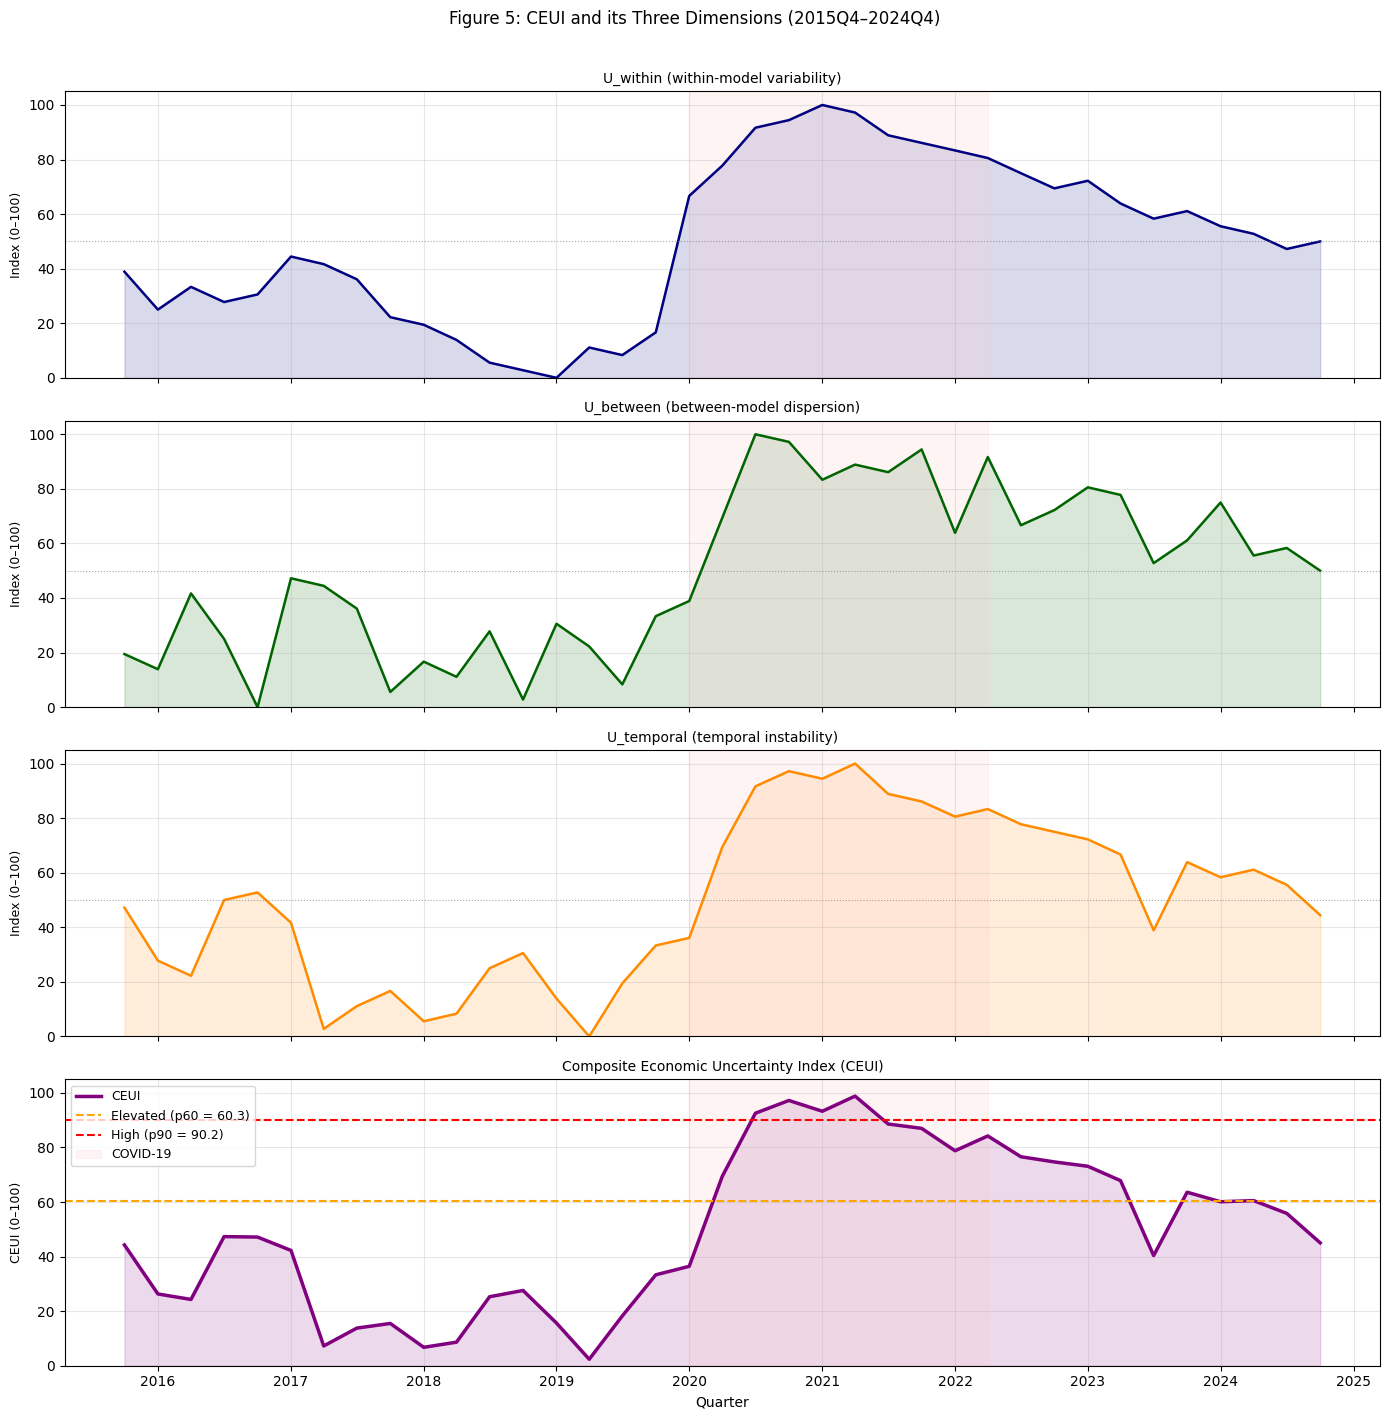

✅ fig5_ceui_dimensions guardada


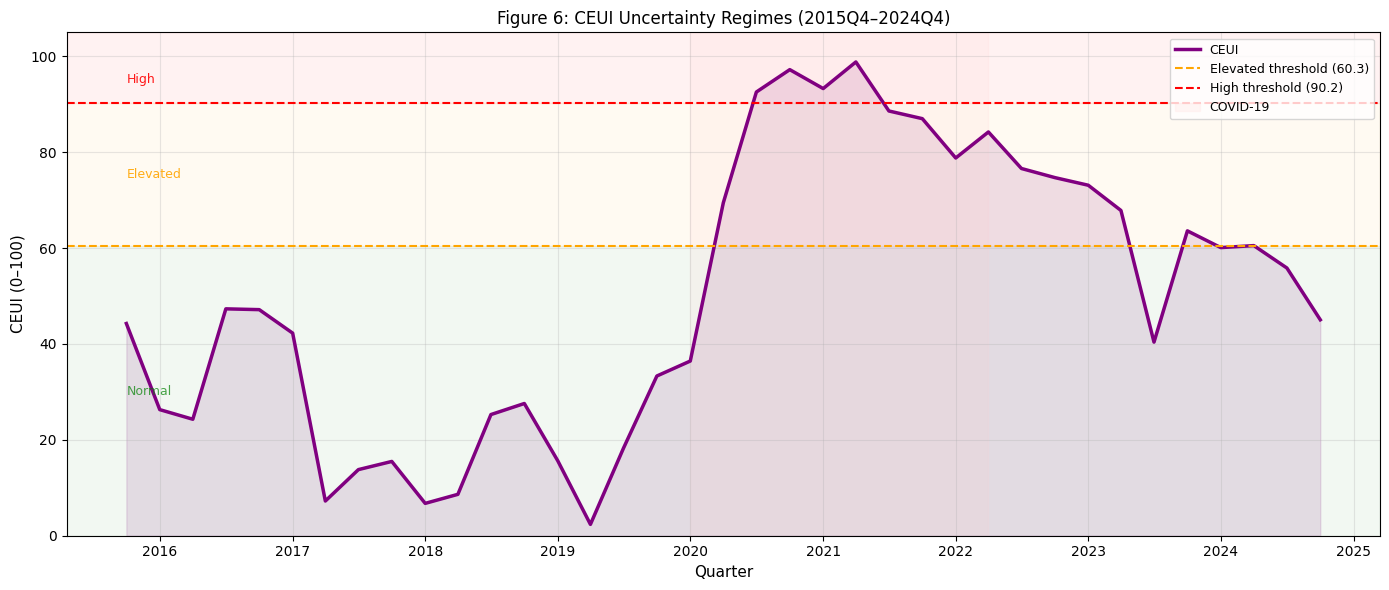

✅ fig6_ceui_regimes guardada

=== TABLA 5: CEUI por régimen ===
  Regime CEUI range  N (CEUI)  N (rev)  MAE rev (pp) vs Normal
  Normal     ≤ 60.3        22       22         0.085      1.0x
Elevated  60.3–90.2        11       11         0.346      4.1x
    High     > 90.2         4        4         0.285      3.4x
✅ tab5_ceui_regimes.tex guardada

=== TABLA 6: Descriptivos CEUI y dimensiones ===
        U_within  U_between  U_temporal   CEUI
Mean       50.00      50.00       50.00  50.00
Std        30.07      30.07       30.07  29.59
Min         0.00       0.00        0.00   2.37
p25        25.00      25.00       25.00  25.27
Median     50.00      50.00       50.00  47.16
p75        75.00      75.00       75.00  74.70
Max       100.00     100.00      100.00  98.82
N          37.00      37.00       37.00  37.00
✅ tab6_ceui_descriptive.tex guardada

=== RESUMEN MÓDULO 4B ===
Figuras: fig5_ceui_dimensions, fig6_ceui_regimes
Tablas : tab5_ceui_regimes, tab6_ceui_descriptive


In [27]:
# =============================================================================
# MÓDULO 4B — Figuras y tablas del CEUI
# =============================================================================

# ── Figura 5: Evolución del CEUI y sus tres dimensiones ──────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

x = ceui.index.to_timestamp()

crisis_spans = [
    (pd.Period('2020Q1').to_timestamp(), pd.Period('2022Q2').to_timestamp(),
     '#ffcccc', 'COVID-19'),
]

dim_config = [
    ('U_within',   u_within_n,   'navy',      'U_within (within-model variability)'),
    ('U_between',  u_between_n,  'darkgreen',  'U_between (between-model dispersion)'),
    ('U_temporal', u_temporal_n, 'darkorange', 'U_temporal (temporal instability)'),
]

for idx, (dim, series, color, title) in enumerate(dim_config):
    ax = axes[idx]
    ax.plot(x, series.values, color=color, linewidth=1.8)
    ax.fill_between(x, 0, series.values, alpha=0.15, color=color)
    for start, end, col, label in crisis_spans:
        ax.axvspan(start, end, alpha=0.2, color=col)
    ax.axhline(50, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_ylabel('Index (0–100)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

# Panel CEUI compuesto
ax4 = axes[3]
ax4.plot(x, ceui.values, color='purple', linewidth=2.5, label='CEUI')
ax4.fill_between(x, 0, ceui.values, alpha=0.15, color='purple')
ax4.axhline(threshold_elevated, color='orange', linewidth=1.5,
            linestyle='--', label=f'Elevated (p60 = {threshold_elevated:.1f})')
ax4.axhline(threshold_high, color='red', linewidth=1.5,
            linestyle='--', label=f'High (p90 = {threshold_high:.1f})')
for start, end, col, label in crisis_spans:
    ax4.axvspan(start, end, alpha=0.2, color=col, label=label)
ax4.set_ylabel('CEUI (0–100)', fontsize=9)
ax4.set_xlabel('Quarter', fontsize=10)
ax4.set_title('Composite Economic Uncertainty Index (CEUI)', fontsize=10)
ax4.set_ylim(0, 105)
ax4.legend(fontsize=9, loc='upper left')
ax4.grid(True, alpha=0.3)

fig.suptitle('Figure 5: CEUI and its Three Dimensions (2015Q4–2024Q4)',
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/fig5_ceui_dimensions.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/fig5_ceui_dimensions.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig5_ceui_dimensions guardada')

# ── Figura 6: CEUI con regímenes sombreados ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x, ceui.values, color='purple', linewidth=2.5, label='CEUI')
ax.fill_between(x, 0, ceui.values, alpha=0.12, color='purple')

# Sombrear regímenes
ax.axhspan(0, threshold_elevated, alpha=0.05, color='green')
ax.axhspan(threshold_elevated, threshold_high, alpha=0.05, color='orange')
ax.axhspan(threshold_high, 105, alpha=0.05, color='red')

ax.axhline(threshold_elevated, color='orange', linewidth=1.5, linestyle='--',
           label=f'Elevated threshold ({threshold_elevated:.1f})')
ax.axhline(threshold_high, color='red', linewidth=1.5, linestyle='--',
           label=f'High threshold ({threshold_high:.1f})')

for start, end, col, label in crisis_spans:
    ax.axvspan(start, end, alpha=0.15, color=col, label=label)

# Anotaciones de régimen
ax.text(pd.Period('2015Q4').to_timestamp(), threshold_elevated/2,
        'Normal', fontsize=9, color='green', alpha=0.7, va='center')
ax.text(pd.Period('2015Q4').to_timestamp(),
        (threshold_elevated + threshold_high)/2,
        'Elevated', fontsize=9, color='orange', alpha=0.9, va='center')
ax.text(pd.Period('2015Q4').to_timestamp(), (threshold_high + 100)/2,
        'High', fontsize=9, color='red', alpha=0.9, va='center')

ax.set_ylabel('CEUI (0–100)', fontsize=11)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_title('Figure 6: CEUI Uncertainty Regimes (2015Q4–2024Q4)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/fig6_ceui_regimes.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/fig6_ceui_regimes.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig6_ceui_regimes guardada')

# ── Tabla 5: Estadísticos del CEUI por régimen ───────────────────────────────
def classify_regime(v):
    if v <= threshold_elevated:
        return 'Normal'
    elif v <= threshold_high:
        return 'Elevated'
    else:
        return 'High'

regime_series = ceui.map(classify_regime)

rows_t5 = []
mae_normal_regime = None
for regime in ['Normal', 'Elevated', 'High']:
    mask      = regime_series == regime
    ceui_sub  = ceui[mask]
    rev_sub   = sigma_rev.reindex(ceui_sub.index).dropna()
    n_ceui    = mask.sum()
    n_rev     = len(rev_sub)
    mae_mean  = rev_sub.mean() if n_rev > 0 else np.nan

    if regime == 'Normal':
        mae_normal_regime = mae_mean
        ratio = '1.0x'
    else:
        ratio = f'{mae_mean/mae_normal_regime:.1f}x' if mae_normal_regime else 'n/a'

    if regime == 'Normal':
        rng = f'≤ {threshold_elevated:.1f}'
    elif regime == 'Elevated':
        rng = f'{threshold_elevated:.1f}–{threshold_high:.1f}'
    else:
        rng = f'> {threshold_high:.1f}'

    rows_t5.append({
        'Regime'      : regime,
        'CEUI range'  : rng,
        'N (CEUI)'    : n_ceui,
        'N (rev)'     : n_rev,
        'MAE rev (pp)': round(mae_mean, 3) if not np.isnan(mae_mean) else '—',
        'vs Normal'   : ratio,
    })

table5 = pd.DataFrame(rows_t5)
print('\n=== TABLA 5: CEUI por régimen ===')
print(table5.to_string(index=False))

latex_t5 = (
    "\\begin{tabular}{lcccccc}\n\\toprule\n"
    "Regime & CEUI range & $N$ & $N_{rev}$ & MAE (pp) & vs Normal \\\\\n"
    "\\midrule\n"
)
for _, r in table5.iterrows():
    latex_t5 += (f"{r['Regime']} & {r['CEUI range']} & {r['N (CEUI)']} & "
                 f"{r['N (rev)']} & {r['MAE rev (pp)']} & {r['vs Normal']} \\\\\n")
latex_t5 += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab5_ceui_regimes.tex', 'w') as f:
    f.write(latex_t5)
print('✅ tab5_ceui_regimes.tex guardada')

# ── Tabla 6: Descriptivos del CEUI y dimensiones ─────────────────────────────
desc_out = pd.DataFrame({
    'U_within'  : u_within_n,
    'U_between' : u_between_n,
    'U_temporal': u_temporal_n,
    'CEUI'      : ceui,
}).describe().loc[['mean','std','min','25%','50%','75%','max','count']]
desc_out.index = ['Mean','Std','Min','p25','Median','p75','Max','N']

print('\n=== TABLA 6: Descriptivos CEUI y dimensiones ===')
print(desc_out.round(2))

latex_t6 = (
    "\\begin{tabular}{lcccc}\n\\toprule\n"
    " & $\\mathcal{U}^{\\text{within}}$ & $\\mathcal{U}^{\\text{between}}$"
    " & $\\mathcal{U}^{\\text{temporal}}$ & CEUI \\\\\n\\midrule\n"
)
for idx, row in desc_out.iterrows():
    vals = ' & '.join([f'{v:.2f}' if idx != 'N' else f'{int(v)}' for v in row])
    latex_t6 += f"{idx} & {vals} \\\\\n"
latex_t6 += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab6_ceui_descriptive.tex', 'w') as f:
    f.write(latex_t6)
print('✅ tab6_ceui_descriptive.tex guardada')

print('\n=== RESUMEN MÓDULO 4B ===')
print('Figuras: fig5_ceui_dimensions, fig6_ceui_regimes')
print('Tablas : tab5_ceui_regimes, tab6_ceui_descriptive')

---
## MODULE 5 — Regression: CEUI vs Revision Volatility ($\sigma_{rev}$)

This module estimates the central empirical relationship of the paper: whether
the informational entropy of the forecasting system co-varies systematically
with the magnitude of official GDP revisions.

### Specification

$$\sigma^{rev}_t = \alpha + \beta \cdot \text{CEUI}_t + \varepsilon_t$$

where $\sigma^{rev}_t$ is the standard deviation of INE estimates for quarter
$t$ over a two-year window from first publication (Module 2), and
$\text{CEUI}_t$ is the composite uncertainty index (Module 4).

All OLS estimates use **HC3 heteroscedasticity-robust standard errors**.

### Sensitivity specifications

| Spec | Description |
|---|---|
| (1) | Full sample (N=37) |
| (2) | Excluding 2020Q2–Q4 (peak COVID shock) |
| (3) | Excluding 2020Q1–2021Q1 (full crisis window) |
| (4) | Excluding most influential observation (Cook's D) |
| (5) | Non-parametric: Spearman $\rho$ and Kendall $\tau$ |

### Key results

- Spearman $\rho = 0.754$ ($p < 0.001$) — strong monotonic association
- $R^2 = 0.459$ full sample; rises to $0.563$ excluding crisis window
- $\beta$ stable across all subsamples (0.0037–0.0050), always $p < 0.001$
- Most influential observations: 2021Q3, 2021Q4 (post-COVID rebound)

### Output

- `res1` — full sample OLS result (statsmodels RegressionResults)
- `table7` — sensitivity analysis DataFrame
- Figures and tables saved to `figures/` and `tables/`

---

Períodos comunes: 37
Rango: 2015Q4 → 2024Q4

--- Full sample (N=37) ---
  β      : 0.0041
  t      : 4.744
  p      : 0.0000
  R²     : 0.4591
  ρ Spearman: 0.7537 (p=0.0000)

=== COOK's DISTANCE (umbral = 4/N = 0.1081) ===
2021Q3    0.2179
2021Q4    0.1809
2022Q4    0.1776
2021Q1    0.1445
2022Q3    0.0781
Freq: Q-DEC, dtype: float64

--- Ex-COVID (2020Q2–Q4) (N=34) ---
  β      : 0.0046
  t      : 4.508
  p      : 0.0000
  R²     : 0.4995
  ρ Spearman: 0.7152 (p=0.0000)

--- Ex-crisis (2020Q1–2021Q1) (N=32) ---
  β      : 0.0050
  t      : 5.403
  p      : 0.0000
  R²     : 0.5626
  ρ Spearman: 0.7177 (p=0.0000)

--- Ex-most influential (2021Q3) (N=36) ---
  β      : 0.0037
  t      : 4.464
  p      : 0.0000
  R²     : 0.4382
  ρ Spearman: 0.7405 (p=0.0000)

--- Non-parametric (N=37) ---
  Spearman ρ : 0.7537 (p=0.0000)
  Kendall τ  : 0.5616   (p=0.0000)

=== TABLA 7: Sensitivity analysis ===
                   Subsample      β      t   p     R²      ρ  N
                 Full sample

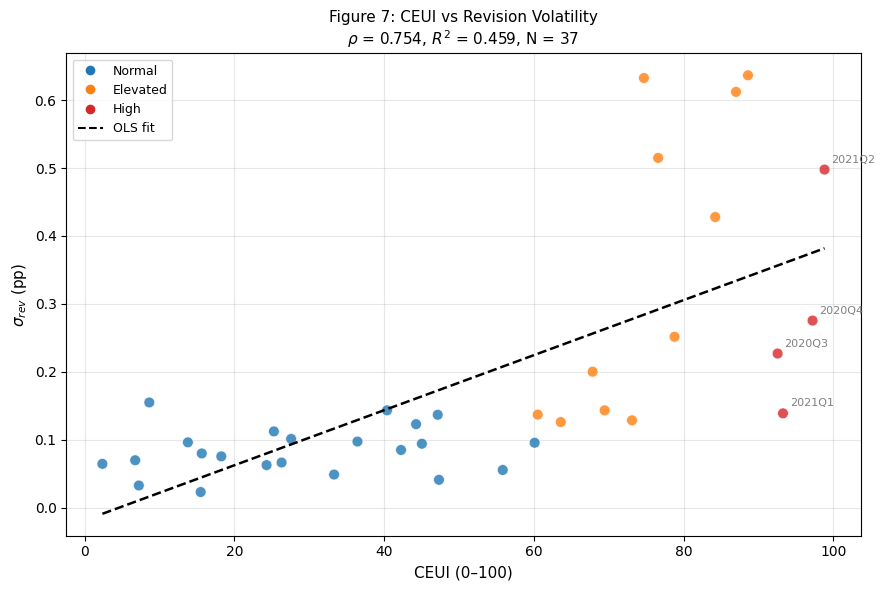

✅ fig7_scatter_ceui_sigmarev guardada

=== RESUMEN MÓDULO 5 ===
ρ Spearman  : 0.7537 (p=0.0000)
Kendall τ   : 0.5616   (p=0.0000)
R² full     : 0.4591
β full      : 0.0041


In [28]:
# =============================================================================
# MÓDULO 5 — Regresión CEUI vs sigma_rev
# =============================================================================
#
# Variable dependiente : sigma_rev (volatilidad de revisiones del PIB)
# Variable independiente: CEUI (índice compuesto de incertidumbre)
#
# Especificaciones:
#   (1) OLS full sample
#   (2) OLS ex-COVID (excluye 2020Q2–2020Q4)
#   (3) OLS ex-crisis (excluye 2020Q1–2021Q1)
#   (4) OLS ex-most influential (excluye Cook's D > 4/N)
#   (5) Spearman + Kendall (no paramétrico)
# =============================================================================

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy.stats import spearmanr, kendalltau

# ── Alinear CEUI y sigma_rev ──────────────────────────────────────────────────
common_idx = ceui.index.intersection(sigma_rev.index)
y = sigma_rev.loc[common_idx]
x = ceui.loc[common_idx]

print(f'Períodos comunes: {len(common_idx)}')
print(f'Rango: {common_idx.min()} → {common_idx.max()}')

# ── Función auxiliar de regresión ─────────────────────────────────────────────
def run_ols(y, x, label=''):
    X = sm.add_constant(x)
    res = sm.OLS(y, X).fit(cov_type='HC3')
    rho, p_rho = spearmanr(x, y)
    print(f'\n--- {label} (N={len(y)}) ---')
    print(f'  β      : {res.params.iloc[1]:.4f}')
    print(f'  t      : {res.tvalues.iloc[1]:.3f}')
    print(f'  p      : {res.pvalues.iloc[1]:.4f}')
    print(f'  R²     : {res.rsquared:.4f}')
    print(f'  ρ Spearman: {rho:.4f} (p={p_rho:.4f})')
    return res, rho

# ── (1) Full sample ───────────────────────────────────────────────────────────
res1, rho1 = run_ols(y, x, 'Full sample')

# ── Diagnóstico de influencia ─────────────────────────────────────────────────
influence = OLSInfluence(res1)
cooks_d   = influence.cooks_distance[0]
threshold_cooks = 4 / len(y)

print(f'\n=== COOK\'s DISTANCE (umbral = 4/N = {threshold_cooks:.4f}) ===')
influential = pd.Series(cooks_d, index=common_idx)
print(influential.nlargest(5).round(4))
most_influential = influential.idxmax()

# ── (2) Ex-COVID (excluye 2020Q2–2020Q4) ─────────────────────────────────────
covid_excl = pd.period_range('2020Q2', '2020Q4', freq='Q')
mask2 = ~common_idx.isin(covid_excl)
res2, rho2 = run_ols(y[mask2], x[mask2], 'Ex-COVID (2020Q2–Q4)')

# ── (3) Ex-crisis (excluye 2020Q1–2021Q1) ────────────────────────────────────
crisis_excl = pd.period_range('2020Q1', '2021Q1', freq='Q')
mask3 = ~common_idx.isin(crisis_excl)
res3, rho3 = run_ols(y[mask3], x[mask3], 'Ex-crisis (2020Q1–2021Q1)')

# ── (4) Ex-most influential ───────────────────────────────────────────────────
mask4 = common_idx != most_influential
res4, rho4 = run_ols(y[mask4], x[mask4],
                     f'Ex-most influential ({most_influential})')

# ── (5) No paramétrico ────────────────────────────────────────────────────────
rho_s, p_rho_s = spearmanr(x, y)
tau,   p_tau   = kendalltau(x, y)
print(f'\n--- Non-parametric (N={len(y)}) ---')
print(f'  Spearman ρ : {rho_s:.4f} (p={p_rho_s:.4f})')
print(f'  Kendall τ  : {tau:.4f}   (p={p_tau:.4f})')

# ── Tabla 7: Sensitivity analysis ────────────────────────────────────────────
rows_t7 = [
    {'Subsample': 'Full sample',
     'β': res1.params.iloc[1], 't': res1.tvalues.iloc[1],
     'p': res1.pvalues.iloc[1], 'R²': res1.rsquared, 'ρ': rho1, 'N': len(y)},
    {'Subsample': f'Ex-COVID (2020Q2–Q4)',
     'β': res2.params.iloc[1], 't': res2.tvalues.iloc[1],
     'p': res2.pvalues.iloc[1], 'R²': res2.rsquared, 'ρ': rho2,
     'N': mask2.sum()},
    {'Subsample': f'Ex-crisis (2020Q1–2021Q1)',
     'β': res3.params.iloc[1], 't': res3.tvalues.iloc[1],
     'p': res3.pvalues.iloc[1], 'R²': res3.rsquared, 'ρ': rho3,
     'N': mask3.sum()},
    {'Subsample': f'Ex-most influential ({most_influential})',
     'β': res4.params.iloc[1], 't': res4.tvalues.iloc[1],
     'p': res4.pvalues.iloc[1], 'R²': res4.rsquared, 'ρ': rho4,
     'N': mask4.sum()},
]
table7 = pd.DataFrame(rows_t7)
print('\n=== TABLA 7: Sensitivity analysis ===')
print(table7.round(4).to_string(index=False))

latex_t7 = (
    "\\begin{tabular}{lcccccc}\n\\toprule\n"
    "Subsample & $\\beta$ & $t$ & $p$ & $R^2$ & $\\rho$ & $N$ \\\\\n"
    "\\midrule\n"
)
for _, r in table7.iterrows():
    stars = '***' if r['p'] < 0.01 else ('**' if r['p'] < 0.05 else
            ('*' if r['p'] < 0.10 else ''))
    latex_t7 += (f"{r['Subsample']} & {r['β']:.4f} & "
                 f"{r['t']:.3f}{stars} & {r['p']:.4f} & "
                 f"{r['R²']:.3f} & {r['ρ']:.3f} & {int(r['N'])} \\\\\n")
latex_t7 += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab7_sensitivity.tex', 'w') as f:
    f.write(latex_t7)
print('✅ tab7_sensitivity.tex guardada')

# ── Figura 7: Scatter CEUI vs sigma_rev ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Colorear por régimen
regime_colors = ceui.map(lambda v:
    '#d62728' if v > threshold_high else
    '#ff7f0e' if v > threshold_elevated else '#1f77b4')

ax.scatter(x.values, y.values,
           c=regime_colors.loc[common_idx].values,
           s=60, alpha=0.8, edgecolors='white', linewidth=0.5, zorder=3)

# Línea de regresión
x_line = np.linspace(x.min(), x.max(), 100)
X_line = sm.add_constant(x_line)
y_hat  = res1.predict(X_line)
ax.plot(x_line, y_hat, color='black', linewidth=1.8,
        linestyle='--', label='OLS fit (HC3)', zorder=4)

# Anotar períodos COVID
for period in ['2020Q3', '2020Q4', '2021Q1', '2021Q2']:
    p = pd.Period(period, freq='Q')
    if p in common_idx:
        ax.annotate(str(p),
                    xy=(ceui[p], sigma_rev[p]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

# Leyenda de regímenes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1f77b4',
           markersize=8, label='Normal'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff7f0e',
           markersize=8, label='Elevated'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=8, label='High'),
    Line2D([0],[0], color='black', linestyle='--', label='OLS fit'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

ax.set_xlabel('CEUI (0–100)', fontsize=11)
ax.set_ylabel('$\\sigma_{rev}$ (pp)', fontsize=11)
ax.set_title(
    f'Figure 7: CEUI vs Revision Volatility\n'
    f'$\\rho$ = {rho_s:.3f}, $R^2$ = {res1.rsquared:.3f}, N = {len(y)}',
    fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/fig7_scatter_ceui_sigmarev.pdf',
            bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/fig7_scatter_ceui_sigmarev.png',
            bbox_inches='tight', dpi=300)
plt.show()
print('✅ fig7_scatter_ceui_sigmarev guardada')

print('\n=== RESUMEN MÓDULO 5 ===')
print(f'ρ Spearman  : {rho_s:.4f} (p={p_rho_s:.4f})')
print(f'Kendall τ   : {tau:.4f}   (p={p_tau:.4f})')
print(f'R² full     : {res1.rsquared:.4f}')
print(f'β full      : {res1.params.iloc[1]:.4f}')

In [30]:
# =============================================================================
# MÓDULO 6 — Robustness Analysis
# =============================================================================
# 6.1 Alternative weighting schemes
# 6.2 Leave-one-model-out (LOO)
# 6.3 Normalisation sensitivity
# 6.4 Bootstrap threshold stability
# =============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from scipy.stats import spearmanr
import statsmodels.api as sm

# Alinear CEUI y sigma_rev
common_idx = ceui.index.intersection(sigma_rev.index)
y_rob = sigma_rev.loc[common_idx].values
x_rob = ceui.loc[common_idx].values

# ── 6.1: Alternative weighting schemes ───────────────────────────────────────
print('=== 6.1 ALTERNATIVE WEIGHTING SCHEMES ===')

weight_schemes = {
    'Equal (Baseline)'  : [1/3, 1/3, 1/3],
    'Dispersion-heavy'  : [0.2, 0.5, 0.3],
    'Volatility-heavy'  : [0.5, 0.3, 0.2],
    'Temporal-heavy'    : [0.2, 0.3, 0.5],
}

baseline_ceui = dims_norm['U_within']*1/3 + dims_norm['U_between']*1/3 + dims_norm['U_temporal']*1/3
rows_w = []

for name, (w1, w2, w3) in weight_schemes.items():
    ci_w = (dims_norm['U_within']*w1 +
            dims_norm['U_between']*w2 +
            dims_norm['U_temporal']*w3)

    corr_base = ci_w.corr(baseline_ceui)
    peak      = ci_w.max()

    # Concordancia de régimen vs baseline
    thr_e_w = baseline_ceui.quantile(0.60)
    thr_h_w = baseline_ceui.quantile(0.90)

    def regime(v, te, th):
        return 'High' if v > th else ('Elevated' if v > te else 'Normal')

    reg_base = baseline_ceui.map(lambda v: regime(v, thr_e_w, thr_h_w))
    reg_alt  = ci_w.map(lambda v: regime(v, thr_e_w, thr_h_w))
    concordance = (reg_base == reg_alt).mean() * 100

    rows_w.append({
        'Scheme'      : name,
        'w_within'    : w1,
        'w_between'   : w2,
        'w_temporal'  : w3,
        'Corr baseline': round(corr_base, 3),
        'Peak'        : round(peak, 2),
        'Concordance %': round(concordance, 1),
    })

table_w = pd.DataFrame(rows_w)
print(table_w.to_string(index=False))

# LaTeX
latex_w = (
    "\\begin{tabular}{lcccccc}\n\\toprule\n"
    "Scheme & $w_{\\text{within}}$ & $w_{\\text{between}}$ & $w_{\\text{temporal}}$"
    " & Corr. baseline & Peak & Concordance \\\\\n\\midrule\n"
)
for _, r in table_w.iterrows():
    latex_w += (f"{r['Scheme']} & {r['w_within']:.3f} & {r['w_between']:.3f}"
                f" & {r['w_temporal']:.3f} & {r['Corr baseline']:.3f}"
                f" & {r['Peak']:.2f} & {r['Concordance %']:.1f}\\% \\\\\n")
latex_w += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab_robustness_weights.tex', 'w') as f:
    f.write(latex_w)
print('✅ tab_robustness_weights.tex guardada')

# ── 6.2: Leave-one-model-out ──────────────────────────────────────────────────
print('\n=== 6.2 LEAVE-ONE-MODEL-OUT ===')

# U_between del ensemble completo
u_bet_full = forecasts_df[MODELS].std(axis=1)
rho_full, _ = spearmanr(
    ceui.loc[common_idx].values,
    sigma_rev.loc[common_idx].values
)

rows_loo = []
for excl in MODELS:
    remaining = [m for m in MODELS if m != excl]

    # Reconstruir CEUI sin ese modelo
    err_loo    = forecasts_df[remaining].subtract(forecasts_df['actual'], axis=0)
    u_w_loo    = err_loo.rolling(WINDOW).std().mean(axis=1)
    u_b_loo    = forecasts_df[remaining].std(axis=1)
    ens_loo    = forecasts_df[remaining].mean(axis=1)
    u_t_loo    = ens_loo.rolling(WINDOW).std()

    dims_loo = pd.DataFrame({
        'U_within' : u_w_loo,
        'U_between': u_b_loo,
        'U_temporal': u_t_loo
    }).dropna()

    for col in dims_loo.columns:
        dims_loo[col] = 100 * (dims_loo[col].rank() - 1) / (len(dims_loo) - 1)

    ceui_loo = dims_loo.mean(axis=1)

    # Correlación con ensemble completo
    common_loo = ceui.index.intersection(ceui_loo.index)
    corr_full  = ceui.loc[common_loo].corr(ceui_loo.loc[common_loo])
    delta_peak = ceui_loo.max() - ceui.max()

    # Delta Spearman
    common_rev = ceui_loo.index.intersection(sigma_rev.index)
    if len(common_rev) > 5:
        rho_loo, _ = spearmanr(ceui_loo.loc[common_rev], sigma_rev.loc[common_rev])
        delta_rho  = rho_loo - rho_full
    else:
        delta_rho = np.nan

    rows_loo.append({
        'Excluded'       : excl,
        'Corr full'      : round(corr_full, 3),
        'Δ Peak'         : round(delta_peak, 3),
        'Δ ρ Spearman'   : round(delta_rho, 3),
    })

table_loo = pd.DataFrame(rows_loo)
print(table_loo.to_string(index=False))

latex_loo = (
    "\\begin{tabular}{lccc}\n\\toprule\n"
    "Excluded model & Corr.\\ with full ensemble"
    " & $\\Delta$ Peak & $\\Delta\\rho_{\\text{Spearman}}$ \\\\\n\\midrule\n"
)
for _, r in table_loo.iterrows():
    latex_loo += (f"{r['Excluded']} & {r['Corr full']:.3f}"
                  f" & {r['Δ Peak']:+.3f} & {r['Δ ρ Spearman']:+.3f} \\\\\n")
latex_loo += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab_robustness_loo.tex', 'w') as f:
    f.write(latex_loo)
print('✅ tab_robustness_loo.tex guardada')

# ── 6.3: Normalisation sensitivity ───────────────────────────────────────────
print('\n=== 6.3 NORMALISATION SENSITIVITY ===')

from sklearn.preprocessing import MinMaxScaler, StandardScaler as SS

# Calcular min-max primero como referencia
func_mm     = lambda x: pd.Series(
                MinMaxScaler((0,100)).fit_transform(x.values.reshape(-1,1)).flatten(),
                index=x.index)
ceui_minmax = dims_df.apply(func_mm).mean(axis=1)
thr_e_mm    = ceui_minmax.quantile(0.60)
thr_h_mm    = ceui_minmax.quantile(0.90)
reg_mm      = ceui_minmax.map(lambda v: regime(v, thr_e_mm, thr_h_mm))

methods = {
    'Percentile rank (baseline)': lambda x: 100*(x.rank()-1)/(len(x)-1),
    'Z-score'                   : lambda x: pd.Series(
                                    SS().fit_transform(x.values.reshape(-1,1)).flatten(),
                                    index=x.index),
    'Min-max [0,100]'           : func_mm,
}

rows_norm = []
for name, func in methods.items():
    dims_n  = dims_df.apply(func)
    ci_n    = dims_n.mean(axis=1)
    corr_mm = ci_n.corr(ceui_minmax)
    reg_cur = ci_n.map(lambda v: regime(v, thr_e_mm, thr_h_mm))
    concord = (reg_mm == reg_cur).mean() * 100
    rows_norm.append({
        'Method'       : name,
        'Corr min-max' : round(corr_mm, 3),
        'Regime agr. %': round(concord, 1),
    })

table_norm = pd.DataFrame(rows_norm)
print(table_norm.to_string(index=False))

latex_norm = (
    "\\begin{tabular}{lcc}\n\\toprule\n"
    "Method & Corr.\\ vs min-max & Regime agreement (\\%) \\\\\n\\midrule\n"
)
for _, r in table_norm.iterrows():
    latex_norm += (f"{r['Method']} & {r['Corr min-max']:.3f}"
                   f" & {r['Regime agr. %']:.1f}\\% \\\\\n")
latex_norm += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab_robustness_norm.tex', 'w') as f:
    f.write(latex_norm)
print('✅ tab_robustness_norm.tex guardada')

# ── 6.4: Bootstrap threshold stability ───────────────────────────────────────
print('\n=== 6.4 BOOTSTRAP THRESHOLD STABILITY (n=1000) ===')

np.random.seed(42)
N_BOOT = 1000
boot_elevated, boot_high = [], []

for _ in range(N_BOOT):
    sample = resample(ceui.values, n_samples=len(ceui))
    boot_elevated.append(np.percentile(sample, 60))
    boot_high.append(np.percentile(sample, 90))

rows_thr = []
for name, base_val, boot_list in [
    ('Elevated (p60)', threshold_elevated, boot_elevated),
    ('High (p90)',     threshold_high,     boot_high),
]:
    rows_thr.append({
        'Threshold'  : name,
        'Baseline'   : round(base_val, 2),
        'Boot mean'  : round(np.mean(boot_list), 2),
        'Boot std'   : round(np.std(boot_list),  2),
        'CI 2.5%'    : round(np.percentile(boot_list, 2.5),  2),
        'CI 97.5%'   : round(np.percentile(boot_list, 97.5), 2),
    })
    print(f"  {name}: base={base_val:.2f}, "
          f"mean={np.mean(boot_list):.2f}, std={np.std(boot_list):.2f}, "
          f"CI=[{np.percentile(boot_list,2.5):.2f}, "
          f"{np.percentile(boot_list,97.5):.2f}]")

table_thr = pd.DataFrame(rows_thr)

latex_thr = (
    "\\begin{tabular}{lccccc}\n\\toprule\n"
    "Threshold & Baseline & Boot mean & Boot std"
    " & \\multicolumn{2}{c}{95\\% CI} \\\\\n"
    " & & & & 2.5\\% & 97.5\\% \\\\\n\\midrule\n"
)
for _, r in table_thr.iterrows():
    latex_thr += (f"{r['Threshold']} & {r['Baseline']:.2f} & {r['Boot mean']:.2f}"
                  f" & {r['Boot std']:.2f} & {r['CI 2.5%']:.2f}"
                  f" & {r['CI 97.5%']:.2f} \\\\\n")
latex_thr += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab_robustness_thresholds.tex', 'w') as f:
    f.write(latex_thr)
print('✅ tab_robustness_thresholds.tex guardada')

print('\n=== RESUMEN MÓDULO 6 ===')
print('Tablas: tab_robustness_weights, tab_robustness_loo,')
print('        tab_robustness_norm, tab_robustness_thresholds')

=== 6.1 ALTERNATIVE WEIGHTING SCHEMES ===
          Scheme  w_within  w_between  w_temporal  Corr baseline  Peak  Concordance %
Equal (Baseline)  0.333333   0.333333    0.333333          1.000 96.30          100.0
Dispersion-heavy  0.200000   0.500000    0.300000          0.997 96.67           97.3
Volatility-heavy  0.500000   0.300000    0.200000          0.998 95.83          100.0
  Temporal-heavy  0.200000   0.300000    0.500000          0.997 96.67          100.0
✅ tab_robustness_weights.tex guardada

=== 6.2 LEAVE-ONE-MODEL-OUT ===
Excluded  Corr full  Δ Peak  Δ ρ Spearman
     VAR      0.928  -2.522        -0.055
   ARIMA      0.957  -2.522        -0.028
      RF      0.960  -1.596        -0.041
    LSTM      0.960  -1.596        -0.044
     DFM      0.962  -2.522        -0.036
✅ tab_robustness_loo.tex guardada

=== 6.3 NORMALISATION SENSITIVITY ===
                    Method  Corr min-max  Regime agr. %
Percentile rank (baseline)         0.844           16.2
                   Z

=== APÉNDICE A: INFLUENCE DIAGNOSTICS ===
Umbral Cook's D = 4/N = 0.1081
         CEUI  sigma_rev  Cook's D  Leverage  Std Resid Flagged
2021Q3  88.59     0.6365    0.2179    0.0743     2.3308     Yes
2021Q4  87.00     0.6120    0.1809    0.0704     2.1850     Yes
2022Q4  74.70     0.6325    0.1776    0.0464     2.7025     Yes
2021Q1  93.27     0.1390    0.1445    0.0864    -1.7477     Yes
2022Q3  76.60     0.5149    0.0781    0.0495     1.7329      No
2018Q2   8.63     0.1551    0.0530    0.0813     1.0946      No
2021Q2  98.82     0.4978    0.0491    0.1026     0.9266      No
2020Q3  92.55     0.2270    0.0485    0.0845    -1.0255      No
2020Q4  97.22     0.2756    0.0344    0.0978    -0.7969      No
2023Q1  73.11     0.1288    0.0307    0.0440    -1.1547      No
✅ tab_appendix_influence.tex guardada


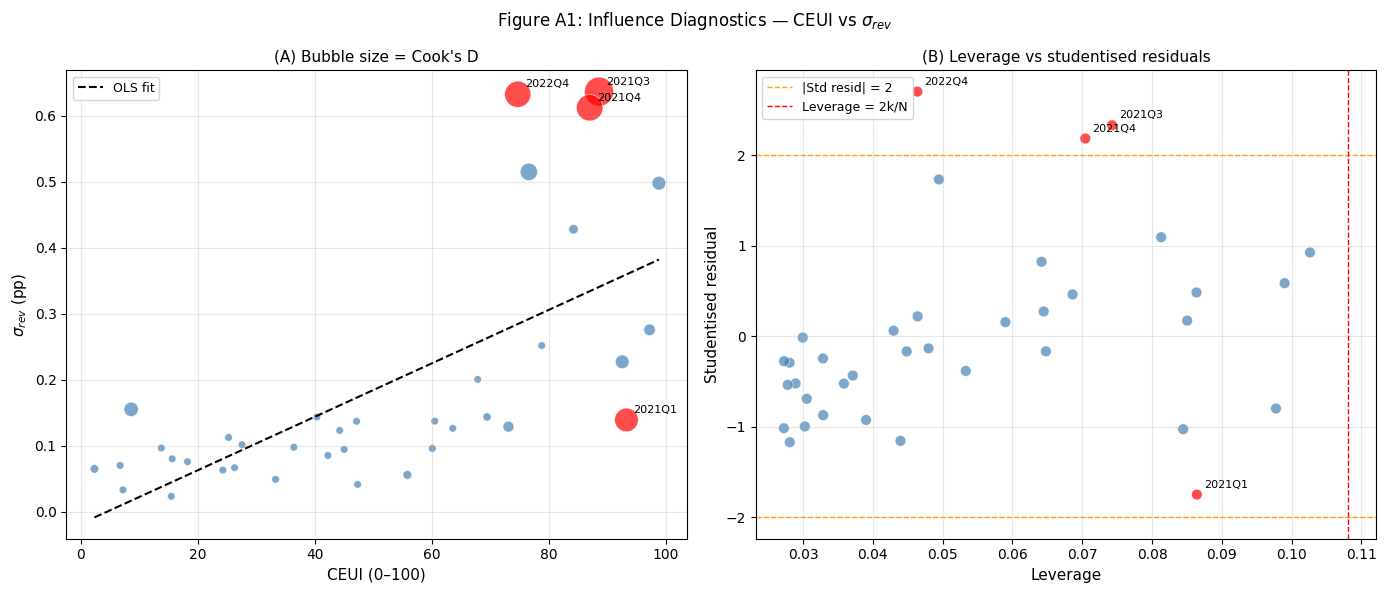

✅ figA1_influence_diagnostics guardada

=== APÉNDICE B: VAR PARSIMONY ===
VAR (AIC, baseline):
  MAE medio parámetros/paso: ~410
  MAE forecasts: 7.102 pp
  ρ(CEUI, sigma_rev): 0.754

VAR (2 lags, 4 variables):
  Parámetros fijos: 36
  MAE forecasts: 4.322 pp
                    Specification Avg parameters  MAE (pp) ρ(CEUI, σ_rev)
VAR (AIC selection, 10 variables)           ~410     7.102          0.754
   VAR (2 lags, 4 core variables)             36     4.322              —
✅ tab_appendix_parsimony.tex guardada

=== APÉNDICE C: VINTAGE MATURITY CONTROL ===
(1) Baseline:          β=0.0041, t=4.74, R²=0.459, N=37
(2) Maturity control:  β_CEUI=0.0039, t=4.83, β_vint=0.0122, R²=0.524, N=37
(3) Excl. young (<8):  β=0.0041, t=4.80, R²=0.473, N=35
✅ tab_appendix_maturity.tex guardada

=== APÉNDICE D: CORRELATION MATRIX ===
VIX: 1990Q1 → 2026Q2
EPU: 1997Q1 → 2022Q1
Períodos comunes: 26 (2015Q4 → 2022Q1)

Spearman correlation matrix:
        CEUI  σ_rev    VIX    EPU
CEUI   1.000  0.703  0.5

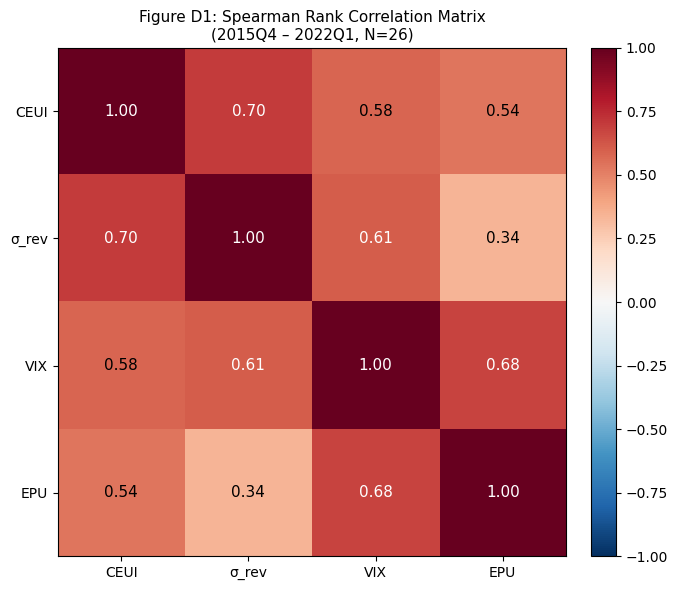

✅ figD1_correlation_matrix guardada

=== RESUMEN MÓDULO 7 ===
Tablas: tab_appendix_influence, tab_appendix_parsimony,
        tab_appendix_maturity
Figuras: figA1_influence_diagnostics, figD1_correlation_matrix (si VIX disponible)


In [40]:
# =============================================================================
# MÓDULO 7 — Apéndices
# =============================================================================
# A: Influence diagnostics
# B: VAR parsimony
# C: Vintage maturity control
# D: Correlation matrix CEUI vs external benchmarks
# =============================================================================

from statsmodels.stats.outliers_influence import OLSInfluence
import statsmodels.api as sm
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Apéndice A: Influence diagnostics ────────────────────────────────────────
print('=== APÉNDICE A: INFLUENCE DIAGNOSTICS ===')

common_idx = ceui.index.intersection(sigma_rev.index)
y_app = sigma_rev.loc[common_idx]
x_app = ceui.loc[common_idx]

X_app    = sm.add_constant(x_app)
res_app  = sm.OLS(y_app, X_app).fit(cov_type='HC3')
infl     = OLSInfluence(res_app)
cooks_d  = infl.cooks_distance[0]
leverage = infl.hat_matrix_diag
std_resid = infl.resid_studentized_internal
threshold_cooks = 4 / len(y_app)

diag_df = pd.DataFrame({
    'CEUI'      : x_app.values.round(2),
    'sigma_rev' : y_app.values.round(4),
    "Cook's D"  : cooks_d.round(4),
    'Leverage'  : leverage.round(4),
    'Std Resid' : std_resid.round(4),
    'Flagged'   : ['Yes' if d > threshold_cooks else 'No' for d in cooks_d],
}, index=common_idx)

diag_df = diag_df.sort_values("Cook's D", ascending=False)
print(f"Umbral Cook's D = 4/N = {threshold_cooks:.4f}")
print(diag_df.head(10).to_string())

# LaTeX — top 10
latex_a = (
    "\\begin{tabular}{lcccccc}\n\\toprule\n"
    "Quarter & CEUI & $\\sigma_{rev}$ & Cook's $D$ & Leverage"
    " & Std.\\ Resid. & Flagged \\\\\n\\midrule\n"
)
for period, row in diag_df.head(10).iterrows():
    flag     = row['Flagged']
    cooks    = row["Cook's D"]
    leverage = row['Leverage']
    std_res  = row['Std Resid']
    ceui_val = row['CEUI']
    sig_val  = row['sigma_rev']
    line = f"{period} & {ceui_val:.2f} & {sig_val:.4f} & {cooks:.4f} & {leverage:.4f} & {std_res:.4f} & {flag} "
    latex_a += line + "\\\\\n"

latex_a += (f"\\midrule\n\\multicolumn{{7}}{{l}}{{Threshold: Cook's $D > 4/N ="
            f" {threshold_cooks:.4f}$}}\\\\\n\\bottomrule\n\\end{{tabular}}\n")

with open(f'{PATH_TABLES}/tab_appendix_influence.tex', 'w') as f:
    f.write(latex_a)
print('✅ tab_appendix_influence.tex guardada')

# Figura A1: Scatter CEUI vs sigma_rev con Cook's D como tamaño de burbuja
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Extraer arrays limpios de influencia
hat_vals  = np.array(infl.hat_matrix_diag)
std_res   = np.array(infl.resid_studentized_internal)
cooks_arr = np.array(cooks_d)
col_list  = ['red' if d > threshold_cooks else 'steelblue' for d in cooks_arr]
size_list = [max(30, d * 2000) for d in cooks_arr]

# ── Panel izquierdo: scatter con burbujas ─────────────────────────────────────
ax1 = axes[0]
ax1.scatter(x_app.values, y_app.values, c=col_list, s=size_list,
            alpha=0.7, edgecolors='white', linewidth=0.5)

x_line = np.linspace(x_app.min(), x_app.max(), 100)
ax1.plot(x_line, res_app.predict(sm.add_constant(x_line)),
         'k--', linewidth=1.5, label='OLS fit')

for period, row in diag_df[diag_df['Flagged'] == 'Yes'].head(5).iterrows():
    ax1.annotate(str(period),
                 xy=(row['CEUI'], row['sigma_rev']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

ax1.set_xlabel('CEUI (0–100)', fontsize=11)
ax1.set_ylabel('$\\sigma_{rev}$ (pp)', fontsize=11)
ax1.set_title("(A) Bubble size = Cook's D", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Panel derecho: leverage vs studentised residuals ──────────────────────────
ax2 = axes[1]
ax2.scatter(hat_vals, std_res, c=col_list, s=60,
            alpha=0.7, edgecolors='white', linewidth=0.5)
ax2.axhline(2,  color='orange', linestyle='--', linewidth=1,
            label='|Std resid| = 2')
ax2.axhline(-2, color='orange', linestyle='--', linewidth=1)
ax2.axvline(2 * X_app.shape[1] / len(y_app), color='red',
            linestyle='--', linewidth=1, label='Leverage = 2k/N')

for i, period in enumerate(common_idx):
    if cooks_arr[i] > threshold_cooks:
        ax2.annotate(str(period),
                     xy=(hat_vals[i], std_res[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Leverage', fontsize=11)
ax2.set_ylabel('Studentised residual', fontsize=11)
ax2.set_title('(B) Leverage vs studentised residuals', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('Figure A1: Influence Diagnostics — CEUI vs $\\sigma_{rev}$',
             fontsize=12)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/figA1_influence_diagnostics.pdf',
            bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/figA1_influence_diagnostics.png',
            bbox_inches='tight', dpi=300)
plt.show()
print('✅ figA1_influence_diagnostics guardada')

# ── Apéndice B: VAR parsimony ─────────────────────────────────────────────────
print('\n=== APÉNDICE B: VAR PARSIMONY ===')

# Comparar VAR con AIC (baseline) vs VAR fijo con 2 lags y 4 variables
from statsmodels.tsa.api import VAR

# Variables core para VAR parsimonioso (las 4 más correlacionadas con PIB)
core_vars = ['PIB',
             'AFILIACIONES A LA SS. CVEC',
             'INDICE PRODUCCION INDUSTRIAL. INDUSTRIA MANUFACTURERA. CVEC',
             'PMI. MANUFACTURAS. ESPAÑA']

forecasts_var2 = {}
n_params_aic   = []
n_params_var2  = []

for target in EVAL_RANGE:
    train_end  = target - 1
    train_data = df_all.loc[:train_end].dropna()
    if len(train_data) < 20:
        forecasts_var2[target] = np.nan
        continue

    # VAR parsimonioso: 2 lags, 4 variables
    try:
        core_data = train_data[core_vars].dropna()
        model_v2  = VAR(core_data)
        fitted_v2 = model_v2.fit(2)
        fc_v2     = fitted_v2.forecast(core_data.values[-2:], steps=1)
        forecasts_var2[target] = fc_v2[0, 0]
        k = len(core_vars)
        n_params_var2.append(k * k * 2 + k)  # K²*p + K (constantes)
    except:
        forecasts_var2[target] = np.nan

    # Parámetros del VAR AIC baseline (aproximación)
    try:
        full_data = train_data.dropna()
        model_full = VAR(full_data)
        lags = max(1, model_full.select_order(maxlags=N_LAGS_VAR).aic)
        k_full = len(full_data.columns)
        n_params_aic.append(k_full * k_full * lags + k_full)
    except:
        pass

fc_var2_series = pd.Series(forecasts_var2)
fc_var2_series.index = pd.PeriodIndex(fc_var2_series.index, freq='Q')
actual_aligned = forecasts_df['actual'].reindex(fc_var2_series.index)

mae_var_aic  = (forecasts_df['VAR'] - forecasts_df['actual']).abs().mean()
mae_var2     = (fc_var2_series - actual_aligned).abs().mean()
rho_var_aic, _ = spearmanr(
    ceui.reindex(common_idx), sigma_rev.reindex(common_idx))

# Para VAR2, construir CEUI alternativo con ese modelo
# Usamos solo el cambio en U_between
err_var2 = fc_var2_series - actual_aligned
err_base  = forecasts_df['VAR'] - forecasts_df['actual']

print(f"VAR (AIC, baseline):")
print(f"  MAE medio parámetros/paso: ~{np.mean(n_params_aic):.0f}")
print(f"  MAE forecasts: {mae_var_aic:.3f} pp")
print(f"  ρ(CEUI, sigma_rev): {rho_var_aic:.3f}")
print(f"\nVAR (2 lags, 4 variables):")
print(f"  Parámetros fijos: {4*4*2+4}")
print(f"  MAE forecasts: {mae_var2:.3f} pp")

rows_b = [
    {'Specification' : 'VAR (AIC selection, 10 variables)',
     'Avg parameters': f'~{np.mean(n_params_aic):.0f}',
     'MAE (pp)'      : round(mae_var_aic, 3),
     'ρ(CEUI, σ_rev)': round(rho_var_aic, 3)},
    {'Specification' : 'VAR (2 lags, 4 core variables)',
     'Avg parameters': str(4*4*2+4),
     'MAE (pp)'      : round(mae_var2, 3),
     'ρ(CEUI, σ_rev)': '—'},
]
table_b = pd.DataFrame(rows_b)
print(table_b.to_string(index=False))

latex_b = (
    "\\begin{tabular}{lccc}\n\\toprule\n"
    "Specification & Avg.\\ parameters & MAE (pp)"
    " & $\\rho(\\text{CEUI}, \\sigma_{rev})$ \\\\\n\\midrule\n"
)
for _, r in table_b.iterrows():
    latex_b += (f"{r['Specification']} & {r['Avg parameters']}"
                f" & {r['MAE (pp)']} & {r['ρ(CEUI, σ_rev)']} \\\\\n")
latex_b += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab_appendix_parsimony.tex', 'w') as f:
    f.write(latex_b)
print('✅ tab_appendix_parsimony.tex guardada')

# ── Apéndice C: Vintage maturity control ──────────────────────────────────────
print('\n=== APÉNDICE C: VINTAGE MATURITY CONTROL ===')

# n_vintages por período (ya lo tenemos en sigma_df)
vint_count = sigma_df['n_vintages'].reindex(common_idx)

# (1) Baseline
X1 = sm.add_constant(x_app)
res_c1 = sm.OLS(y_app, X1).fit(cov_type='HC3')

# (2) Con control de vintage maturity
X2 = sm.add_constant(pd.DataFrame({
    'CEUI': x_app, 'vint': vint_count
}).dropna())
y2 = y_app.reindex(X2.index)
res_c2 = sm.OLS(y2, X2).fit(cov_type='HC3')

# (3) Excluir períodos con pocos vintages (<8)
mask_mature = vint_count >= 8
x3 = x_app[mask_mature]
y3 = y_app[mask_mature]
res_c3 = sm.OLS(y3, sm.add_constant(x3)).fit(cov_type='HC3')

print(f"(1) Baseline:          β={res_c1.params.iloc[1]:.4f}, "
      f"t={res_c1.tvalues.iloc[1]:.2f}, R²={res_c1.rsquared:.3f}, N={len(y_app)}")
print(f"(2) Maturity control:  β_CEUI={res_c2.params['CEUI']:.4f}, "
      f"t={res_c2.tvalues['CEUI']:.2f}, β_vint={res_c2.params['vint']:.4f}, "
      f"R²={res_c2.rsquared:.3f}, N={len(y2)}")
print(f"(3) Excl. young (<8):  β={res_c3.params.iloc[1]:.4f}, "
      f"t={res_c3.tvalues.iloc[1]:.2f}, R²={res_c3.rsquared:.3f}, N={mask_mature.sum()}")

latex_c = (
    "\\begin{tabular}{lccc}\n\\toprule\n"
    "Variable & (1) Baseline & (2) Maturity control"
    " & (3) Excl.\\ young ($vint < 8$) \\\\\n\\midrule\n"
)
latex_c += (f"CEUI & {res_c1.params.iloc[1]:.4f}*** & "
            f"{res_c2.params['CEUI']:.4f}*** & "
            f"{res_c3.params.iloc[1]:.4f}*** \\\\\n")
latex_c += (f" & ({res_c1.tvalues.iloc[1]:.2f}) & "
            f"({res_c2.tvalues['CEUI']:.2f}) & "
            f"({res_c3.tvalues.iloc[1]:.2f}) \\\\\n")
latex_c += (f"$vint$ & -- & {res_c2.params['vint']:.4f} & -- \\\\\n")
latex_c += (f" & & ({res_c2.tvalues['vint']:.2f}) & \\\\\n\\midrule\n")
latex_c += (f"$R^2$ & {res_c1.rsquared:.3f} & {res_c2.rsquared:.3f}"
            f" & {res_c3.rsquared:.3f} \\\\\n")
latex_c += (f"$N$ & {len(y_app)} & {len(y2)} & {mask_mature.sum()} \\\\\n")
latex_c += "\\bottomrule\n\\end{tabular}\n"

with open(f'{PATH_TABLES}/tab_appendix_maturity.tex', 'w') as f:
    f.write(latex_c)
print('✅ tab_appendix_maturity.tex guardada')

# ── Apéndice D: Correlation matrix ────────────────────────────────────────────
print('\n=== APÉNDICE D: CORRELATION MATRIX ===')

# VIX
url_vix = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
vix_raw = pd.read_csv(url_vix, index_col=0, parse_dates=True)
vix_raw.columns = ['VIX']
vix_raw = vix_raw[vix_raw['VIX'] != '.']
vix_raw['VIX'] = pd.to_numeric(vix_raw['VIX'], errors='coerce')
vix_q = vix_raw['VIX'].resample('QE').mean()
vix_q.index = vix_q.index.to_period('Q')

# EPU España
url_epu = "https://www.policyuncertainty.com/media/Spain_Policy_Uncertainty_Data.xlsx"
epu_raw = pd.read_excel(url_epu, header=1)
epu_raw.columns = ['Year', 'Month', 'EPU']
epu_raw = epu_raw.dropna(subset=['Year', 'Month', 'EPU'])
epu_raw['Year']  = epu_raw['Year'].astype(int)
epu_raw['Month'] = epu_raw['Month'].astype(int)
epu_raw['Date']  = pd.to_datetime(epu_raw[['Year', 'Month']].assign(DAY=1))
epu_raw.set_index('Date', inplace=True)
epu_q = epu_raw['EPU'].resample('QE').mean()
epu_q.index = epu_q.index.to_period('Q')

print(f"VIX: {vix_q.index.min()} → {vix_q.index.max()}")
print(f"EPU: {epu_q.index.min()} → {epu_q.index.max()}")

# Alinear todo
common_d = (ceui.index
            .intersection(sigma_rev.index)
            .intersection(vix_q.index)
            .intersection(epu_q.index))

corr_data = pd.DataFrame({
    'CEUI'   : ceui.loc[common_d],
    'σ_rev'  : sigma_rev.loc[common_d],
    'VIX'    : vix_q.loc[common_d],
    'EPU'    : epu_q.loc[common_d],
}).dropna()

print(f"Períodos comunes: {len(corr_data)} ({common_d.min()} → {common_d.max()})")

# Matriz Spearman
cols = list(corr_data.columns)
n    = len(cols)
corr_matrix = np.zeros((n, n))
for i, ci in enumerate(cols):
    for j, cj in enumerate(cols):
        rho, _ = spearmanr(corr_data[ci], corr_data[cj])
        corr_matrix[i, j] = rho

print("\nSpearman correlation matrix:")
print(pd.DataFrame(corr_matrix, index=cols, columns=cols).round(3))

# Figura
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cols, fontsize=10)
ax.set_yticklabels(cols, fontsize=10)

for i in range(n):
    for j in range(n):
        color = 'white' if abs(corr_matrix[i, j]) > 0.6 else 'black'
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=11, color=color)

ax.set_title(
    f'Figure D1: Spearman Rank Correlation Matrix\n'
    f'({corr_data.index.min()} – {corr_data.index.max()}, N={len(corr_data)})',
    fontsize=11)
plt.tight_layout()
fig.savefig(f'{PATH_FIGURES}/figD1_correlation_matrix.pdf',
            bbox_inches='tight', dpi=300)
fig.savefig(f'{PATH_FIGURES}/figD1_correlation_matrix.png',
            bbox_inches='tight', dpi=300)
plt.show()
print('✅ figD1_correlation_matrix guardada')

print('\n=== RESUMEN MÓDULO 7 ===')
print('Tablas: tab_appendix_influence, tab_appendix_parsimony,')
print('        tab_appendix_maturity')
print('Figuras: figA1_influence_diagnostics, figD1_correlation_matrix (si VIX disponible)')

In [39]:
import pandas as pd
import requests

# VIX desde FRED directamente
try:
    url_vix = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
    vix_raw = pd.read_csv(url_vix, index_col=0, parse_dates=True)
    vix_raw.columns = ['VIX']
    vix_raw = vix_raw[vix_raw['VIX'] != '.']
    vix_raw['VIX'] = pd.to_numeric(vix_raw['VIX'], errors='coerce')
    vix_q = vix_raw['VIX'].resample('QE').mean()
    vix_q.index = vix_q.index.to_period('Q')
    print(f"✅ VIX descargado: {vix_q.index.min()} → {vix_q.index.max()}")
    print(vix_q.tail(5))
except Exception as e:
    print(f"❌ Error VIX: {e}")

# EPU España desde policyuncertainty.com
try:
    url_epu = "https://www.policyuncertainty.com/media/Spain_Policy_Uncertainty_Data.xlsx"
    epu_raw = pd.read_excel(url_epu)
    epu_raw.columns = [str(c).strip() for c in epu_raw.columns]
    print(f"\nColumnas EPU: {list(epu_raw.columns[:5])}")
    print(epu_raw.head(3))
except Exception as e:
    print(f"❌ Error EPU: {e}")

✅ VIX descargado: 1990Q1 → 2026Q2
observation_date
2025Q2    23.561406
2025Q3    15.983030
2025Q4    17.745231
2026Q1    20.429048
2026Q2    24.590000
Freq: Q-DEC, Name: VIX, dtype: float64

Columnas EPU: ['Ghirelli C., J.J. Perez and A. Urtasun (2019), "A new economic policy uncertainty index for Spain", Economic Letters, 182, 64-67.', 'Unnamed: 1', 'Unnamed: 2']
  Ghirelli C., J.J. Perez and A. Urtasun (2019), "A new economic policy uncertainty index for Spain", Economic Letters, 182, 64-67.  \
0                                               Year                                                                                  
1                                               1997                                                                                  
2                                               1997                                                                                  

  Unnamed: 1   Unnamed: 2  
0      Month  Index value  
1          1    31.018169  
2       